In [ ]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")
import os
import pickle
import torch

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

import seaborn as sns

from scipy import stats
from itertools import combinations

import umap

from data import create_dataset, load_data, preprocess_data
import interpretation.latentspace as ls
from interpretation import attentions as att
from interpretation import visualization as viz
import interpretation.predictions as prds

import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import linkage, leaves_list

sns.set_style("ticks")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.5,
    "axes.grid": False,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.labelweight": "bold",
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "legend.frameon": False,
    "legend.fontsize": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


## Note
**To run next step, you need to run script `model_analysis.py` first. It trains all models and stores results in csv files and model weights info in pkl files. Then you can load saved CSV files and visualise results.**

In [ ]:
analysis_folder = 'analysis docs'
file_path_comsamples = 'com/metrics/final_results.csv' 
file_path_allsamples = 'all/metrics/final_results.csv'
df = pd.read_csv(os.path.join(analysis_folder, file_path_comsamples))
fold_results_path = os.path.join(analysis_folder, "all/fold_results/fold_results_Multi_seed0_all_samples.pkl")
with open(fold_results_path, 'rb') as f:
    fold_results = pickle.load(f)
df_all_stratify = pd.read_csv(os.path.join(analysis_folder, file_path_allsamples))
df.head()

,model,seed,fold,combination,train_auc,val_auc,precision,recall,f1,accuracy,specificity,n_samples,tn,fp,fn,tp,model_path,selection_criteria,run_id,timestamp
0,ATAC,0,1,all_samples,0.939785,0.859649,0.716981,1.000000,0.835165,0.716981,0.0,53,0,15,0,38,/home/kaveh/Documents/Codes/Columbia/cellfate/...,common_samples,ATAC_seed0_fold1_all_samples,2025-10-03 22:19:24
1,ATAC,0,1,common_samples,0.939785,0.916667,0.727273,1.000000,0.842105,0.727273,0.0,33,0,9,0,24,/home/kaveh/Documents/Codes/Columbia/cellfate/...,common_samples,ATAC_seed0_fold1_common_samples,2025-10-03 22:19:24
2,ATAC,0,2,all_samples,0.899247,0.952632,0.716981,1.000000,0.835165,0.716981,0.0,53,0,15,0,38,/home/kaveh/Documents/Codes/Columbia/cellfate/...,common_samples,ATAC_seed0_fold2_all_samples,2025-10-03 22:19:24
3,ATAC,0,2,common_samples,0.899247,0.916667,0.727273,1.000000,0.842105,0.727273,0.0,33,0,9,0,24,/home/kaveh/Documents/Codes/Columbia/cellfate/...,common_samples,ATAC_seed0_fold2_common_samples,2025-10-03 22:19:24
4,ATAC,0,3,all_samples,0.919010,0.744932,0.804878,0.891892,0.846154,0.773585,0.5,53,8,8,4,33,/home/kaveh/Documents/Codes/Columbia/cellfate/...,common_samples,ATAC_seed0_fold3_all_samples,2025-10-03 22:19:24



Metric: Validation AUC (val_auc) [combination: common_samples]
  Multi  : mean = 0.9402, std = 0.0572
  RNA    : mean = 0.9067, std = 0.0630
  ATAC   : mean = 0.8951, std = 0.0717
  Flux   : mean = 0.8504, std = 0.0969


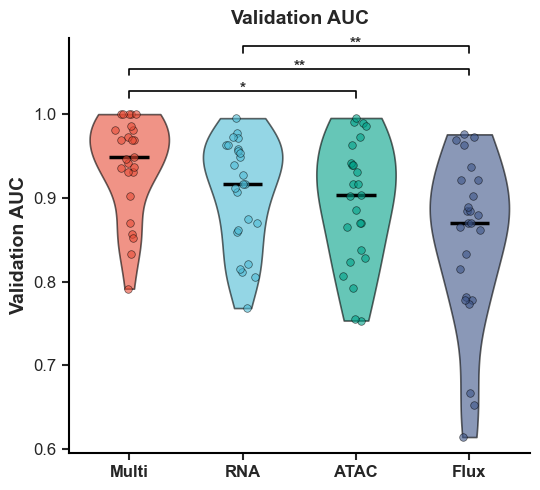

In [ ]:
def add_significance_bars(ax, data_to_plot, models, y_max, y_min, test='mannwhitney'):
    comparisons = list(combinations(range(len(models)), 2))
    y_range = y_max - y_min
    h = y_range * 0.02
    y_start = y_max + y_range * 0.05
    
    sig_pairs = []
    for i, (idx1, idx2) in enumerate(comparisons):
        data1 = data_to_plot[idx1]
        data2 = data_to_plot[idx2]
        
        if test == 'mannwhitney':
            stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        elif test == 'ttest':
            stat, p_value = stats.ttest_rel(data1, data2)
        else:
            raise ValueError("test must be 'mannwhitney' or 'ttest'")
        
        if p_value < 0.001:
            sig = '***'
        elif p_value < 0.01:
            sig = '**'
        elif p_value < 0.05:
            sig = '*'
        else:
            continue
        
        sig_pairs.append((idx1, idx2, sig, p_value))
    
    max_y_sig = y_start
    for level, (idx1, idx2, sig, p_value) in enumerate(sig_pairs):
        y = y_start + (level * h * 3.5)
        x1, x2 = idx1 + 1, idx2 + 1
        
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], 'k-', lw=1.2)
        ax.text((x1 + x2) / 2, y + h*0.3, sig, ha='center', va='bottom', 
                fontsize=11, fontweight='bold')
        max_y_sig = max(max_y_sig, y + h + h*0.3)
    
    return max_y_sig

def plot_all_metrics(df, combination='common_samples', plot_type='violin', test='mannwhitney', metrics=None, print_stats=False):
    all_metrics = ['val_auc', 'precision', 'recall', 'f1', 'accuracy', 'specificity']
    all_metric_labels = ['Validation AUC', 'Precision', 'Recall', 'F1 Score', 'Accuracy', 'Specificity']
    metric_label_map = dict(zip(all_metrics, all_metric_labels))
    if metrics is None:
        metrics_to_plot = all_metrics
        metric_labels = all_metric_labels
    elif isinstance(metrics, str):
        metrics_to_plot = [metrics]
        metric_labels = [metric_label_map.get(metrics, metrics)]
    elif isinstance(metrics, (list, tuple)):
        metrics_to_plot = list(metrics)
        metric_labels = [metric_label_map.get(m, m) for m in metrics_to_plot]
    else:
        raise ValueError("metrics must be None, a string, or a list/tuple of strings")
    df_filtered = df[df['combination'] == combination].copy()
    models = ['Multi', 'RNA', 'ATAC', 'Flux']
    colors = ['#E64B35', '#4DBBD5', '#00A087', '#3C5488']
    n_metrics = len(metrics_to_plot)
    ncols = min(3, n_metrics)
    nrows = (n_metrics + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows))
    if n_metrics == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    for idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
        ax = axes[idx]
        data_to_plot = [df_filtered[df_filtered['model'] == model][metric].values for model in models]
        if print_stats:
            print(f"\nMetric: {label} ({metric}) [combination: {combination}]")
            for model, values in zip(models, data_to_plot):
                if len(values) == 0:
                    mean_val, std_val = float('nan'), float('nan')
                else:
                    mean_val, std_val = np.mean(values), np.std(values)
                print(f"  {model:7s}: mean = {mean_val:.4f}, std = {std_val:.4f}")
        if plot_type == 'violin':
            parts = ax.violinplot(data_to_plot, showmeans=False, showmedians=True, showextrema=False, widths=0.7)
            for i, pc in enumerate(parts['bodies']):
                pc.set_facecolor(colors[i])
                pc.set_alpha(0.6)
                pc.set_edgecolor('black')
                pc.set_linewidth(1.2)
            if 'cmedians' in parts:
                parts['cmedians'].set_color('black')
                parts['cmedians'].set_linewidth(2.5)
            for i, y in enumerate(data_to_plot):
                x = np.random.normal(i+1, 0.05, size=len(y))
                ax.scatter(x, y, color=colors[i], alpha=0.6, edgecolor='black', s=30, linewidth=0.5, zorder=3)
        elif plot_type == 'box':
            bp = ax.boxplot(data_to_plot, labels=models, patch_artist=True,
                           widths=0.6, showmeans=False, meanline=False,
                           medianprops=dict(color='black', linewidth=2.5),
                           boxprops=dict(linewidth=1.2),
                           whiskerprops=dict(linewidth=1.2),
                           capprops=dict(linewidth=1.2))
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
        y_max = max([max(d) if len(d) > 0 else 0 for d in data_to_plot])
        y_min = min([min(d) if len(d) > 0 else 0 for d in data_to_plot])
        y_range = y_max - y_min
        max_y_sig = add_significance_bars(ax, data_to_plot, models, y_max, y_min, test=test)
        ax.set_ylim(y_min - 0.05 * y_range, max_y_sig + 0.02 * y_range)
        ax.set_xticks(np.arange(1, len(models)+1))
        ax.set_xticklabels(models, fontsize=12, fontweight='bold')
        ax.set_ylabel(label, fontsize=14, fontweight='bold')
        ax.set_title(f'{label}', fontsize=14, fontweight='bold', pad=10)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['bottom'].set_linewidth(1.5)
        sns.despine(ax=ax, trim=False)
    for j in range(n_metrics, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    return fig

def plot_pvalue_matrices(df, combination='common_samples', test='ttest'):
    df_filtered = df[df['combination'] == combination].copy()
    
    metrics = ['val_auc', 'precision', 'recall', 'f1', 'accuracy', 'specificity']
    metric_labels = ['Validation AUC', 'Precision', 'Recall', 'F1 Score', 'Accuracy', 'Specificity']
    
    models = ['Multi', 'RNA', 'ATAC', 'Flux']
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[idx]
        
        pvalue_matrix = np.zeros((len(models), len(models)))
        sig_matrix = np.empty((len(models), len(models)), dtype=object)
        
        for i, model1 in enumerate(models):
            for j, model2 in enumerate(models):
                if i == j:
                    pvalue_matrix[i, j] = 1.0
                    sig_matrix[i, j] = '-'
                else:
                    data1 = df_filtered[df_filtered['model'] == model1][metric].values
                    data2 = df_filtered[df_filtered['model'] == model2][metric].values
                    # Choose test
                    if test == 'ttest':
                        stat, p_value = stats.ttest_rel(data1, data2)
                        test_name = 't-test'
                    elif test == 'mannwhitney':
                        # Use two-sided alternative for Mann-Whitney
                        try:
                            stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
                        except ValueError:
                            # If either group is empty, set p_value to nan
                            p_value = np.nan
                        test_name = 'Mann-Whitney U'
                    else:
                        raise ValueError("test must be 'ttest' or 'mannwhitney'")
                    pvalue_matrix[i, j] = p_value
                    
                    if np.isnan(p_value):
                        sig_matrix[i, j] = 'NA'
                    elif p_value < 0.001:
                        sig_matrix[i, j] = '***'
                    elif p_value < 0.01:
                        sig_matrix[i, j] = '**'
                    elif p_value < 0.05:
                        sig_matrix[i, j] = '*'
                    else:
                        sig_matrix[i, j] = 'ns'
        
        annot_matrix = np.array([[f'{pvalue_matrix[i,j]:.4f}\n{sig_matrix[i,j]}' 
                                  for j in range(len(models))] 
                                 for i in range(len(models))])
        
        mask = np.triu(np.ones_like(pvalue_matrix, dtype=bool), k=1)
        
        sns.heatmap(pvalue_matrix, annot=annot_matrix, fmt='',
                    cmap='RdYlGn_r',
                    xticklabels=models, yticklabels=models,
                    vmin=0, vmax=0.1, cbar_kws={'label': 'p-value'},
                    ax=ax, mask=mask, linewidths=1, linecolor='black',
                    annot_kws={'fontsize': 14})
        
        ax.set_title(f'{label} - P-values ({test_name})', fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel('Model', fontsize=11, fontweight='bold')
        ax.set_ylabel('Model', fontsize=11, fontweight='bold')
    
    fig.suptitle(f'Statistical Significance Between Models - {combination.replace("_", " ").title()}', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    return fig

def print_model_seeds_table(df, model='Multi', combination='common_samples'):
    df_filtered = df[(df['combination'] == combination) & (df['model'] == model)].copy()
    
    seeds = [0, 6, 42, 123, 1000]
    metrics = ['val_auc', 'precision', 'recall', 'f1', 'accuracy', 'specificity']
    
    metric_labels = {
        'val_auc': 'Val AUC',
        'precision': 'Precision',
        'recall': 'Recall',
        'f1': 'F1 Score',
        'accuracy': 'Accuracy',
        'specificity': 'Specificity'
    }
    
    results = []
    
    for seed in seeds:
        seed_data = df_filtered[df_filtered['seed'] == seed]
        row = {'Seed': seed}
        
        for metric in metrics:
            mean_val = seed_data[metric].mean()
            std_val = seed_data[metric].std()
            row[metric_labels[metric]] = f'{mean_val:.3f} ± {std_val:.3f}'
        
        results.append(row)
    
    results_df = pd.DataFrame(results)
    results_df = results_df.set_index('Seed')
    
    print(f"\n{'='*100}")
    print(f"{model} Model - {combination.replace('_', ' ').title()}")
    print(f"{'='*100}")
    print(results_df.to_string())
    print(f"{'='*100}\n")
    
    return results_df

def plot_confusion_matrices(df, combination='common_samples', seed=0):
    if seed is None:
        df_filtered = df[df['combination'] == combination].copy()
        seed_label = 'All Seeds'
    else:
        df_filtered = df[(df['combination'] == combination) & (df['seed'] == seed)].copy()
        seed_label = f'Seed {seed}'
    
    models = ['Multi', 'RNA', 'ATAC', 'Flux']
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for idx, model in enumerate(models):
        ax = axes[idx]
        
        model_data = df_filtered[df_filtered['model'] == model]
        
        tn = model_data['tn'].sum()
        fp = model_data['fp'].sum()
        fn = model_data['fn'].sum()
        tp = model_data['tp'].sum()
        
        cm = np.array([[tn, fp], [fn, tp]])
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        labels = np.array([[f'{count:.0f}\n({norm:.2%})' 
                           for count, norm in zip(row_counts, row_norms)]
                          for row_counts, row_norms in zip(cm, cm_normalized)])
        
        sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
                   xticklabels=['Dead End', 'Reprogramming'],
                   yticklabels=['Dead End', 'Reprogramming'],
                   ax=ax, cbar_kws={'label': 'Count', 'pad': 0.02},
                   linewidths=2, linecolor='white',
                   square=True,
                   annot_kws={'fontsize': 14, 'fontweight': 'bold'})
        
        total = tn + fp + fn + tp
        accuracy = (tn + tp) / total if total > 0 else 0
        ax.set_title(f'{model} (n={int(total)}, Acc={accuracy:.3f})', 
                    fontsize=14, fontweight='bold', pad=12)
        ax.set_xlabel('Predicted', fontsize=13, fontweight='bold', labelpad=8)
        ax.set_ylabel('True', fontsize=13, fontweight='bold', labelpad=8)
        ax.tick_params(labelsize=12, width=1.5, length=5)
        
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')
        
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=11, width=1.5, length=5)
        cbar.outline.set_linewidth(1.5)
        cbar.ax.set_ylabel('Count', fontsize=12, fontweight='bold', rotation=270, labelpad=20)
    
    fig.suptitle(f'Confusion Matrices - {combination.replace("_", " ").title()} ({seed_label})', 
                fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    
    return fig

def plot_metric_by_model_seed(df, metric='val_auc', combination='common_samples'):
    df_filtered = df[df['combination'] == combination].copy()
    
    models = ['Multi', 'RNA', 'ATAC', 'Flux']
    seeds = [0, 6, 42, 123, 1000]
    
    metric_labels = {
        'val_auc': 'Validation AUC',
        'precision': 'Precision',
        'recall': 'Recall',
        'f1': 'F1 Score',
        'accuracy': 'Accuracy',
        'specificity': 'Specificity'
    }
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    x = np.arange(len(models))
    width = 0.15
    offsets = np.arange(len(seeds)) * width - (len(seeds) - 1) * width / 2
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(seeds)))
    
    for seed_idx, seed in enumerate(seeds):
        means = []
        stds = []
        
        for model in models:
            data = df_filtered[(df_filtered['model'] == model) & (df_filtered['seed'] == seed)][metric].values
            means.append(data.mean())
            stds.append(data.std())
        
        bars = ax.bar(x + offsets[seed_idx], means, width, 
                      yerr=stds, capsize=3, 
                      label=f'Seed {seed}', 
                      color=colors[seed_idx],
                      alpha=0.8)
        
        for i, (bar, mean) in enumerate(zip(bars, means)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., 0.1,
                   f'{mean:.3f}',
                   ha='center', va='bottom', fontsize=12, rotation=90)
    
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric_labels.get(metric, metric), fontsize=12)
    ax.set_title(f'{metric_labels.get(metric, metric)} by Model and Seed - {combination.replace("_", " ").title()}', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend(fontsize=10, ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.08))
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.15])
    
    plt.tight_layout()
    
    return fig

def print_metrics_table(df, combination='common_samples', seed=None):
    if seed is None:
        df_filtered = df[df['combination'] == combination].copy()
        title_seed = 'All Seeds'
    else:
        df_filtered = df[(df['combination'] == combination) & (df['seed'] == seed)].copy()
        title_seed = f'Seed {seed}'
    
    models = ['Multi', 'RNA', 'ATAC', 'Flux']
    metrics = ['val_auc', 'precision', 'recall', 'f1', 'accuracy', 'specificity']
    
    metric_labels = {
        'val_auc': 'Val AUC',
        'precision': 'Precision',
        'recall': 'Recall',
        'f1': 'F1 Score',
        'accuracy': 'Accuracy',
        'specificity': 'Specificity'
    }
    
    results = []
    metric_means = {metric: [] for metric in metrics}
    
    for model in models:
        model_data = df_filtered[df_filtered['model'] == model]
        row = {'Model': model}
        
        n_samples = int(model_data['n_samples'].sum())
        row['N Samples'] = n_samples
        
        for metric in metrics:
            mean_val = model_data[metric].mean()
            std_val = model_data[metric].std()
            row[metric_labels[metric]] = f'{mean_val:.3f} ± {std_val:.3f}'
            metric_means[metric].append(mean_val)
        
        results.append(row)
    
    results_df = pd.DataFrame(results)
    results_df = results_df.set_index('Model')
    
    print(f"\n{'='*110}")
    print(f"Metrics Summary - {combination.replace('_', ' ').title()} - {title_seed}")
    print(f"{'='*110}")
    print(results_df.to_string())
    print(f"{'='*110}\n")
    
    for metric in metrics:
        max_idx = np.argmax(metric_means[metric])
        print(f"Best {metric_labels[metric]}: {models[max_idx]}")
    print()
    
    return results_df

def save_fig_as_pdf(fig, filename):
    fig.savefig(filename, format='pdf', bbox_inches='tight')

fig1 = plot_all_metrics(df, combination='common_samples', plot_type='violin', test='ttest', metrics=['val_auc'], print_stats=True)
save_fig_as_pdf(fig1, os.path.join(analysis_folder, 'common_samples_auc_compare.pdf'))
plt.show()

Multi - val_auc: 0.9402 ± 0.0572
Multi - precision: 0.9033 ± 0.0525
Multi - recall: 0.9695 ± 0.0307
Multi - f1: 0.9341 ± 0.0306
Multi - accuracy: 0.8993 ± 0.0480
Multi - specificity: 0.7100 ± 0.1680
RNA - val_auc: 0.9067 ± 0.0630
RNA - precision: 0.8852 ± 0.0343
RNA - recall: 0.9580 ± 0.0410
RNA - f1: 0.9194 ± 0.0263
RNA - accuracy: 0.8774 ± 0.0394
RNA - specificity: 0.6572 ± 0.1213
ATAC - val_auc: 0.8951 ± 0.0717
ATAC - precision: 0.8626 ± 0.0793
ATAC - recall: 0.9680 ± 0.0382
ATAC - f1: 0.9092 ± 0.0418
ATAC - accuracy: 0.8553 ± 0.0750
ATAC - specificity: 0.5539 ± 0.3065
Flux - val_auc: 0.8504 ± 0.0969
Flux - precision: 0.8774 ± 0.0496
Flux - recall: 0.9327 ± 0.0505
Flux - f1: 0.9027 ± 0.0350
Flux - accuracy: 0.8529 ± 0.0552
Flux - specificity: 0.6367 ± 0.1810


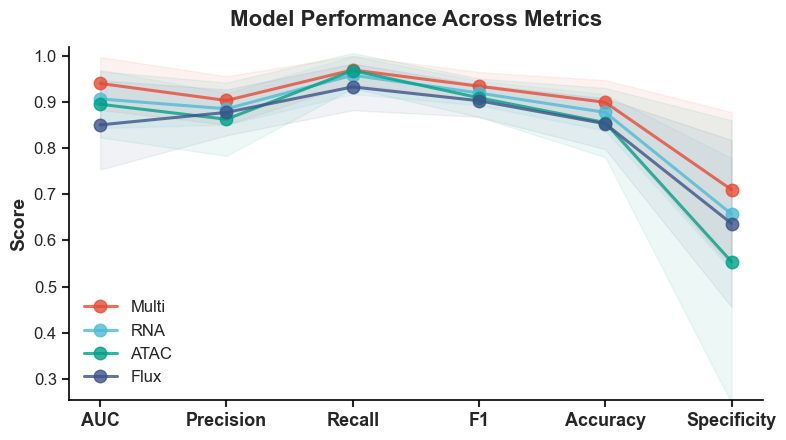

In [ ]:
def plot_metrics_parallel(df, combination='common_samples', figsize=(8, 4.5), print_stats=False):
    all_metrics = ['val_auc', 'precision', 'recall', 'f1', 'accuracy', 'specificity']
    all_metric_labels = ['AUC', 'Precision', 'Recall', 'F1', 'Accuracy', 'Specificity']
    
    df_filtered = df[df['combination'] == combination].copy()
    models = ['Multi', 'RNA', 'ATAC', 'Flux']
    colors = ['#E64B35', '#4DBBD5', '#00A087', '#3C5488']
    
    fig, ax = plt.subplots(figsize=figsize)
    
    x_positions = np.arange(len(all_metrics))
    all_values = []
    
    for idx, model in enumerate(models):
        values = []
        stds = []
        for metric in all_metrics:
            data = df_filtered[df_filtered['model'] == model][metric].values
            if len(data) > 0:
                mean_val = np.mean(data)
                std_val = np.std(data)
                values.append(mean_val)
                stds.append(std_val)
                if print_stats:
                    print(f"{model} - {metric}: {mean_val:.4f} ± {std_val:.4f}")
            else:
                values.append(0)
                stds.append(0)
        all_values.extend(values)
        ax.plot(x_positions, values, 'o-', linewidth=2.2, label=model, 
                color=colors[idx], markersize=9, alpha=0.8)
        
        ax.fill_between(
            x_positions, 
            np.array(values) - np.array(stds), 
            np.array(values) + np.array(stds), 
            alpha=0.07, color=colors[idx]
        )
    
    min_val = max(0, min(all_values) - 0.3)
    max_val = min(1.05, max(all_values) + 0.05)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(all_metric_labels, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score', fontsize=14, fontweight='bold')
    ax.set_ylim(min_val, max_val)
    ax.set_title('Model Performance Across Metrics', fontsize=16, fontweight='bold', pad=15)
    ax.legend(fontsize=12, frameon=False, loc='lower left')
    # No grid
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    plt.tight_layout()
    return fig


fig = plot_metrics_parallel(df, combination='common_samples', print_stats=True)
plt.show()

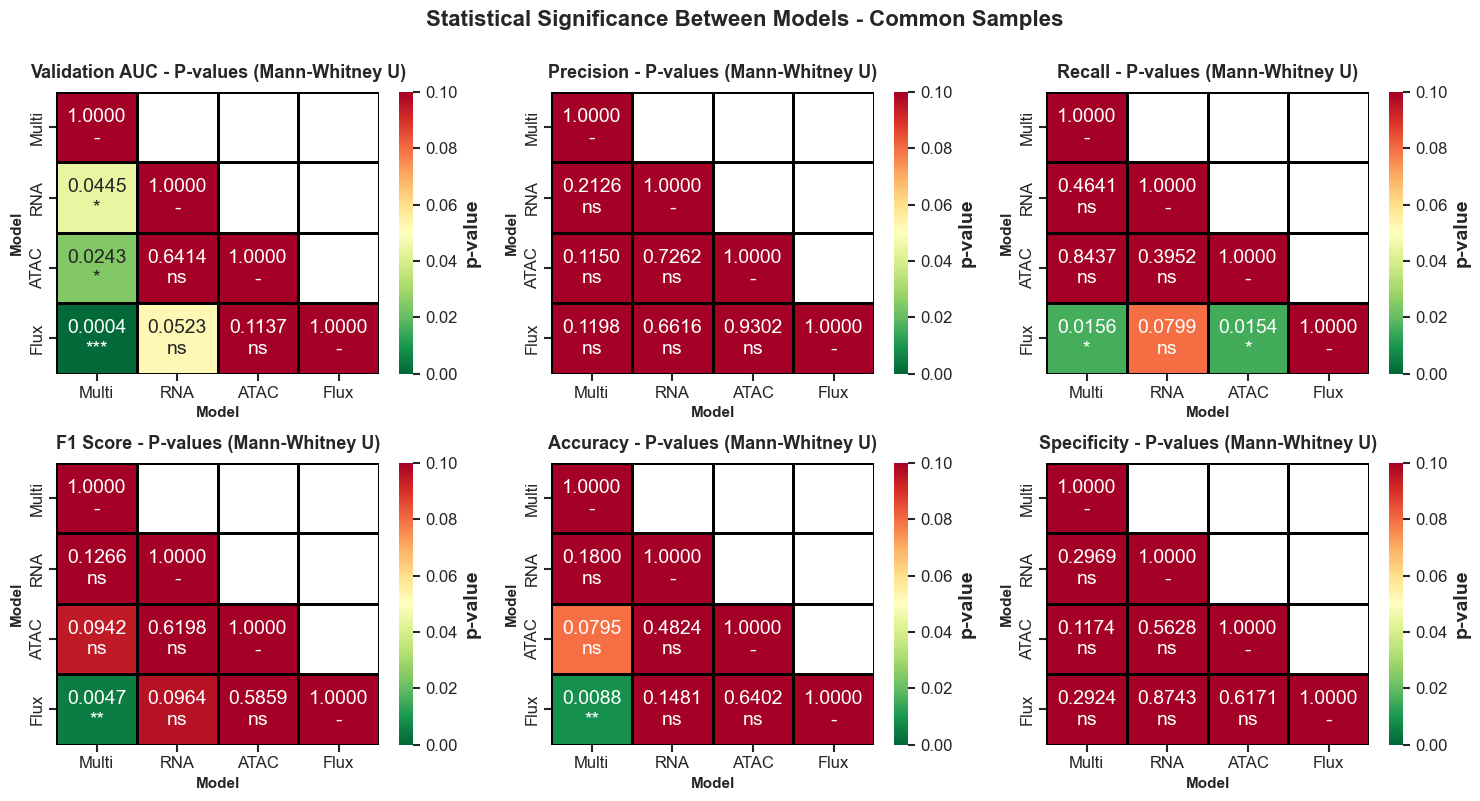

In [6]:
fig = plot_pvalue_matrices(df, combination='common_samples', test='mannwhitney')
plt.show()

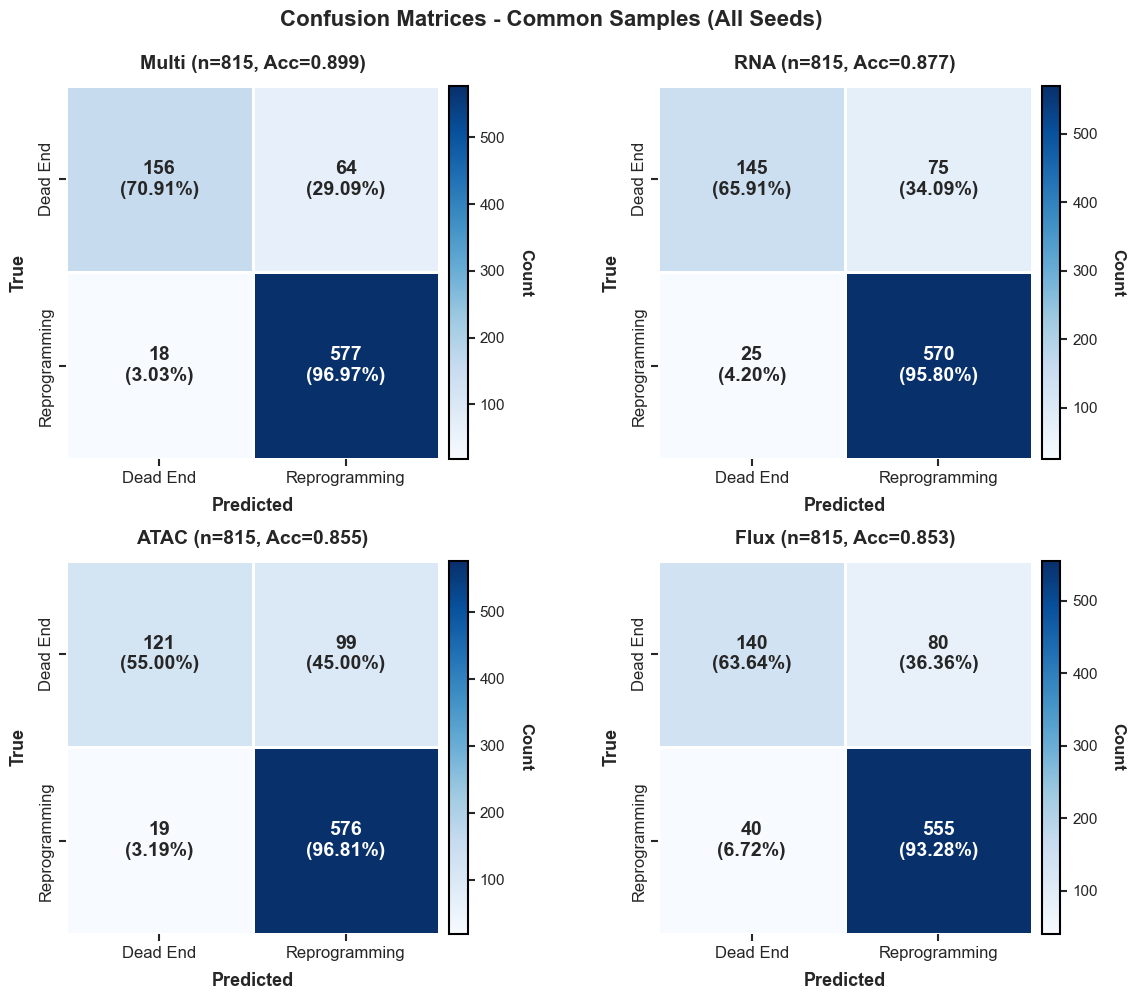

In [ ]:
fig = plot_confusion_matrices(df, combination='common_samples', seed=None)
save_fig_as_pdf(fig, os.path.join(analysis_folder, 'common_samples_confusion_matrix.pdf'))
plt.show()

In [ ]:
table = print_metrics_table(df_all_stratify, combination='all_samples', seed=0)


Metrics Summary - All Samples - Seed 0
       N Samples        Val AUC      Precision         Recall       F1 Score       Accuracy    Specificity
Model                                                                                                     
Multi       2110  0.921 ± 0.020  0.913 ± 0.025  0.937 ± 0.017  0.924 ± 0.011  0.893 ± 0.017  0.795 ± 0.068
RNA         2008  0.920 ± 0.014  0.889 ± 0.021  0.959 ± 0.015  0.923 ± 0.009  0.888 ± 0.014  0.725 ± 0.059
ATAC         265  0.880 ± 0.071  0.856 ± 0.101  0.963 ± 0.044  0.903 ± 0.060  0.849 ± 0.102  0.571 ± 0.365
Flux        2008  0.831 ± 0.010  0.849 ± 0.053  0.855 ± 0.087  0.847 ± 0.019  0.787 ± 0.020  0.632 ± 0.204

Best Val AUC: Multi
Best Precision: Multi
Best Recall: ATAC
Best F1 Score: Multi
Best Accuracy: Multi
Best Specificity: Multi



## Load datasets

In [ ]:
share_config = {
    "d_model": 128,
    "d_ff": 16,
    "n_heads": 8,
    "n_encoder_layers": 2,
    "n_batches": 3,
    "dropout_rate": 0.0,
}


adata_RNA_labelled, adata_RNA_unlabelled, df_rna_degs, adata_RNA_labelled_all = load_data.load_processed_rna(verbose=True, 
                                                                                                         return_raw=True, 
                                                                                                         return_all_features=True)


rna_dataset, _, _ = create_dataset.get_cls_dataset(
        data=adata_RNA_labelled,
        batch_key="batch_no",
        label_key="label", 
        pct_key="pct",
        filter_pcts=0.0,
        data_dtype=torch.int32
    )

adata_ATAC_labelled, adata_ATAC_unlabelled = load_data.load_atac(data_path="datasets/all_atac_d3_motif.h5ad",
                                                                 clone_info=True, clone_path="datasets/clones.csv")


atac_dataset, _, _ = create_dataset.get_cls_dataset(
            data=adata_ATAC_labelled,
            batch_key="batch_no",
            label_key="label",
            pct_key="pct", 
            filter_pcts=0.0,
            data_dtype=torch.float32
        )

fluxes = load_data.load_flux("datasets/flux_labelled.csv", prefix="flux_un",
                                                                 clone_info=True, clone_path="datasets/clones.csv", scale=True)
adata_Flux_labelled, adata_Flux_unlabelled, bi_labelled, bi_unlabelled, flux_labels, pcts_flux = fluxes


flux_dataset, _, _ = create_dataset.get_cls_dataset(
    data=(adata_Flux_labelled, flux_labels, bi_labelled, pcts_flux),
    batch_key=None,
    label_key=None,
    pct_key=None,
    filter_pcts=0.0,
    data_dtype=torch.float32
)

df_rna_degs = df_rna_degs.rename(columns={"gene": "feature", "mean_exp_de": "mean_de", "mean_exp_re": "mean_re", "std_exp_de": "std_de", "std_exp_re": "std_re"})
df_rna_degs["mean_diff"] = df_rna_degs["mean_de"] - df_rna_degs["mean_re"]
df_atac_degs = preprocess_data.get_atac_degs(adata_ATAC_labelled)
df_flux_degs = preprocess_data.get_flux_degs(adata_Flux_labelled, flux_labels)


X, y_label, b, df_indices, pcts = create_dataset.get_pair_modalities(adata_RNA_labelled, 
                                                               adata_ATAC_labelled, 
                                                               adata_Flux_labelled, 
                                                               include_unused_atacs=True,
                                                               seed=42)

feature_names = list(X[0].columns) + ['batch_rna'] + list(X[1].columns) + ['batch_atac'] + list(X[2].columns) + ['batch_flux']

y_number = torch.tensor([{'reprogramming':1, 'dead-end':0}[i] for i in list(y_label)], 
                        dtype=torch.float32)

multimodal_dataset = create_dataset.MultiModalDataset(X, b, y_number)

model_config_rna = {"vocab_size": 5914, "seq_len": X[0].shape[1]}
model_config_atac = {"vocab_size": 1, "seq_len": X[1].shape[1]}
model_config_flux = {"vocab_size": 1, "seq_len": X[2].shape[1]}
model_config_multi = {"d_model": 128, "n_heads_cls": 8, "d_ff_cls": 16}

model_config = {"Share": share_config, "RNA": model_config_rna, "ATAC": model_config_atac, 
                "Flux": model_config_flux, "Multi": model_config_multi}

In [11]:
df_samples = prds.get_sample_predictions_dataframe(
    model_type='Multi',
    multimodal_dataset=multimodal_dataset,
    fold_results=fold_results,
    model_config=model_config,
    device='cpu',
    batch_size=32,
    threshold=0.5
)

Processing 5 folds...
  Fold 1: 422 samples processed
  Fold 2: 422 samples processed
  Fold 3: 422 samples processed
  Fold 4: 422 samples processed
  Fold 5: 422 samples processed

Total samples: 2110
Correct predictions: 1885 (89.34%)
Mean absolute error: 0.1560


In [ ]:
common_samples = False
ls_v, labels, preds = ls.get_latent_space("Multi", fold_results, multimodal_dataset, model_config, 'cpu', common_samples=common_samples)

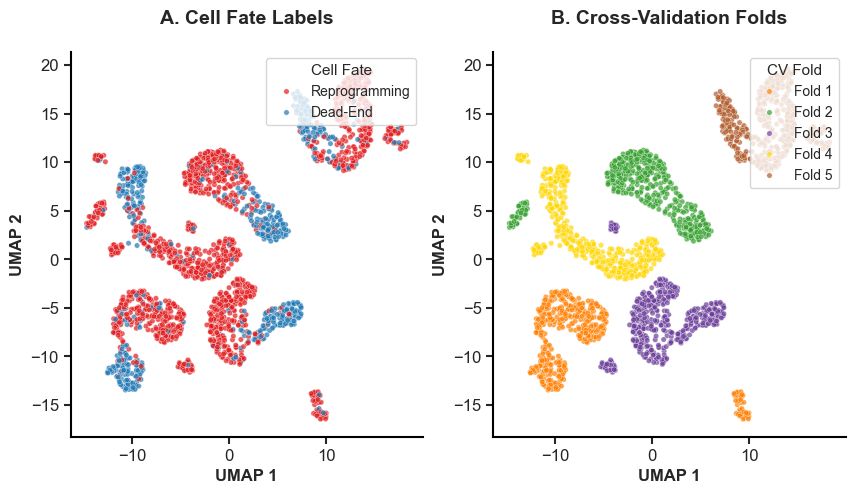

In [13]:
def plot_latent_space(ls_v, labels, preds, fold_results, common_samples=False, plot_type='umap'):
    if plot_type == 'umap':
        reducer = umap.UMAP(n_components=2, random_state=0, n_neighbors=30, min_dist=1)
        reduced_latent_space = reducer.fit_transform(ls_v)
    elif plot_type == 'pca':
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        reduced_latent_space = pca.fit_transform(ls_v)
        explained_variance = pca.explained_variance_ratio_
        print(f"Variance explained by Component 1: {explained_variance[0]:.2f}")
        print(f"Variance explained by Component 2: {explained_variance[1]:.2f}")
        print(f"Total variance explained: {sum(explained_variance):.2f}")

    fold_assignment = []
    for fold_idx, fold in enumerate(fold_results):
        if common_samples:
            val_idx = fold['common_val_indices']
        else:
            val_idx = fold['val_idx']
        fold_assignment.extend([f'Fold {fold_idx + 1}'] * len(val_idx))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8))

    labels_mapped = ['Reprogramming' if label == 1.0 else 'Dead-End' for label in labels.flatten()]
    df_labels = pd.DataFrame({
        'UMAP 1': reduced_latent_space[:, 0],
        'UMAP 2': reduced_latent_space[:, 1],
        'Cell Fate': labels_mapped
    })

    colors_fate = ['#E31A1C', '#1F78B4']  # Red for Dead-End, Blue for Reprogramming
    sns.scatterplot(data=df_labels, x='UMAP 1', y='UMAP 2', hue='Cell Fate', 
                    palette=colors_fate, s=15, alpha=0.7, ax=ax1, rasterized=True)
    ax1.set_title('A. Cell Fate Labels', fontsize=14, fontweight='bold', pad=20)
    ax1.set_xlabel('UMAP 1', fontsize=12)
    ax1.set_ylabel('UMAP 2', fontsize=12)
    ax1.legend(title='Cell Fate', title_fontsize=11, fontsize=10, 
            loc='upper right', frameon=True)

    df_folds = pd.DataFrame({
        'UMAP 1': reduced_latent_space[:, 0],
        'UMAP 2': reduced_latent_space[:, 1],
        'Fold': fold_assignment
    })

    colors_folds = ['#FF7F00', '#33A02C', '#6A3D9A', '#FFD700', '#B15928']
    sns.scatterplot(data=df_folds, x='UMAP 1', y='UMAP 2', hue='Fold', 
                    palette=colors_folds[:len(fold_results)], s=15, alpha=0.7, ax=ax2)
    ax2.set_title('B. Cross-Validation Folds', fontsize=14, fontweight='bold', pad=20)
    ax2.set_xlabel('UMAP 1', fontsize=12)
    ax2.set_ylabel('UMAP 2', fontsize=12)
    ax2.legend(title='CV Fold', title_fontsize=11, fontsize=10, 
            loc='upper right', frameon=True)

    for ax in [ax1, ax2]:
        ax.set_axisbelow(True)
        ax.set_aspect('equal', adjustable='box')

    return fig

fig = plot_latent_space(ls_v, labels, preds, fold_results, common_samples=common_samples, plot_type='umap')
save_fig_as_pdf(fig, os.path.join(analysis_folder, 'latent_space_umap.pdf'))
plt.show()

In [ ]:
device = 'cpu'
fi_shift_flux = ls.analyze_feature_importance_multi("Multi", model_config, fold_results, multimodal_dataset, feature_names, device, 
                                                      analyse_features='Flux', 
                                                      perturbation_scale=0.1, common_samples=True)
fi_shift_atac = ls.analyze_feature_importance_multi("Multi", model_config, fold_results, multimodal_dataset, feature_names, device, 
                                                      analyse_features='ATAC', 
                                                      perturbation_scale=0.15, common_samples=True)
fi_shift_rna = ls.analyze_feature_importance_multi("Multi", model_config, fold_results, multimodal_dataset, feature_names, device, 
                                                      analyse_features='RNA', 
                                                      perturbation_scale=0.1, common_samples=True)

In [15]:
all_indices = df_samples.index.tolist()
de_preds_indices = df_samples[df_samples["predicted_class"] == "dead-end"].index.tolist()
re_preds_indices = df_samples[df_samples["predicted_class"] == "reprogramming"].index.tolist()

all_layers_attentions_all = att.analyze_cls_attention("Multi", fold_results, multimodal_dataset, model_config, device='cpu', 
                                            indices=all_indices, average_heads=False, return_flow_attention=True)
all_layers_attentions_dead_end = att.analyze_cls_attention("Multi", fold_results, multimodal_dataset, model_config, device='cpu', 
                                                 indices=de_preds_indices, average_heads=False, return_flow_attention=True)
all_layers_attentions_reprogramming = att.analyze_cls_attention("Multi", fold_results, multimodal_dataset, model_config, device='cpu', 
                                                      indices=re_preds_indices, average_heads=False, return_flow_attention=True)

# get attention for last layer and heads
cls_layer_attentions_all = att.analyze_cls_attention("Multi", fold_results, multimodal_dataset, model_config, device='cpu', 
                                            indices=all_indices, average_heads=False, return_flow_attention=False)
cls_layer_attentions_dead_end = att.analyze_cls_attention("Multi", fold_results, multimodal_dataset, model_config, device='cpu', 
                                                 indices=de_preds_indices, average_heads=False, return_flow_attention=False)
cls_layer_attentions_reprogramming = att.analyze_cls_attention("Multi", fold_results, multimodal_dataset, model_config, device='cpu', 
                                                      indices=re_preds_indices, average_heads=False, return_flow_attention=False)

rollout_attention_all = att.multimodal_attention_rollout(all_layers_attentions_all)
rollout_attention_dead_end = att.multimodal_attention_rollout(all_layers_attentions_dead_end)
rollout_attention_reprogramming = att.multimodal_attention_rollout(all_layers_attentions_reprogramming)

rollout_attention_all = rollout_attention_all / rollout_attention_all.sum(dim=-1, keepdim=True)
rollout_attention_dead_end = rollout_attention_dead_end / rollout_attention_dead_end.sum(dim=-1, keepdim=True)
rollout_attention_reprogramming = rollout_attention_reprogramming / rollout_attention_reprogramming.sum(dim=-1, keepdim=True)

cls_layer_attentions_all_avg = cls_layer_attentions_all.mean(axis=1) # Average over heads
cls_layer_attentions_dead_end_avg = cls_layer_attentions_dead_end.mean(axis=1)
cls_layer_attentions_reprogramming_avg = cls_layer_attentions_reprogramming.mean(axis=1)

(163, 1998) all_attention.shape
(36, 1998) dead_end_attention.shape
(127, 1998) reprogramming_attention.shape


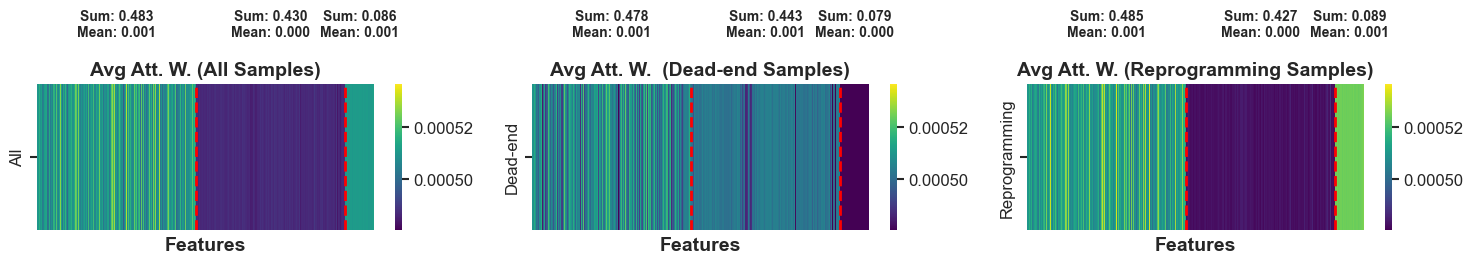

torch.Size([163, 1998]) all_attention.shape
torch.Size([36, 1998]) dead_end_attention.shape
torch.Size([127, 1998]) reprogramming_attention.shape


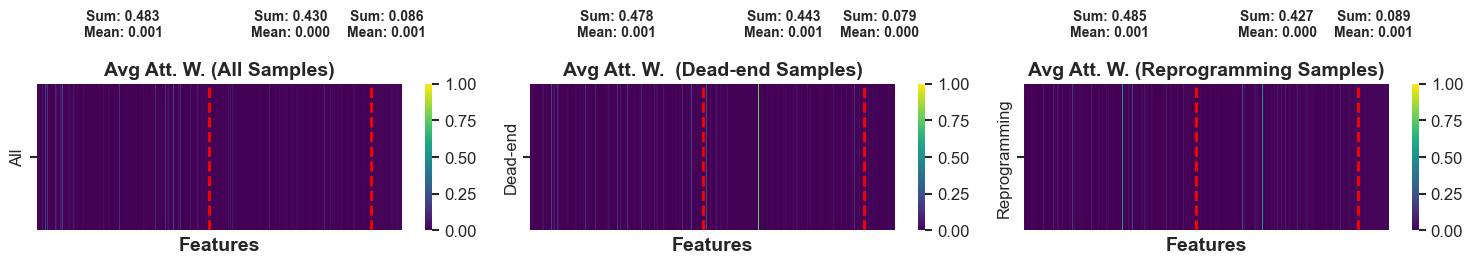

In [16]:
f = viz.plot_att_weights(cls_layer_attentions_all_avg, cls_layer_attentions_dead_end_avg, 
                        cls_layer_attentions_reprogramming_avg, 
                     feature_names=feature_names, print_top_features=False, top_n=5, scale_weights=False,
                     use_mean_contribution='sum', fix_scale=True)
viz.plot_att_weights(rollout_attention_all, rollout_attention_dead_end, rollout_attention_reprogramming, 
                     feature_names=feature_names, print_top_features=False, top_n=5, scale_weights=True,
                     use_mean_contribution='sum')

save_fig_as_pdf(f, os.path.join(analysis_folder, 'attention_weights_cls.pdf'))

Mean attention weight values per modality and per condition:
All - RNA: mean=0.00051129, std=0.00001925
All - ATAC: mean=0.00048696, std=0.00001862
All - Flux: mean=0.00051095, std=0.00002896
Dead-end - RNA: mean=0.00050599, std=0.00002776
Dead-end - ATAC: mean=0.00050151, std=0.00002780
Dead-end - Flux: mean=0.00046453, std=0.00001951
Reprogramming - RNA: mean=0.00051280, std=0.00001572
Reprogramming - ATAC: mean=0.00048284, std=0.00001221
Reprogramming - Flux: mean=0.00052411, std=0.00001358


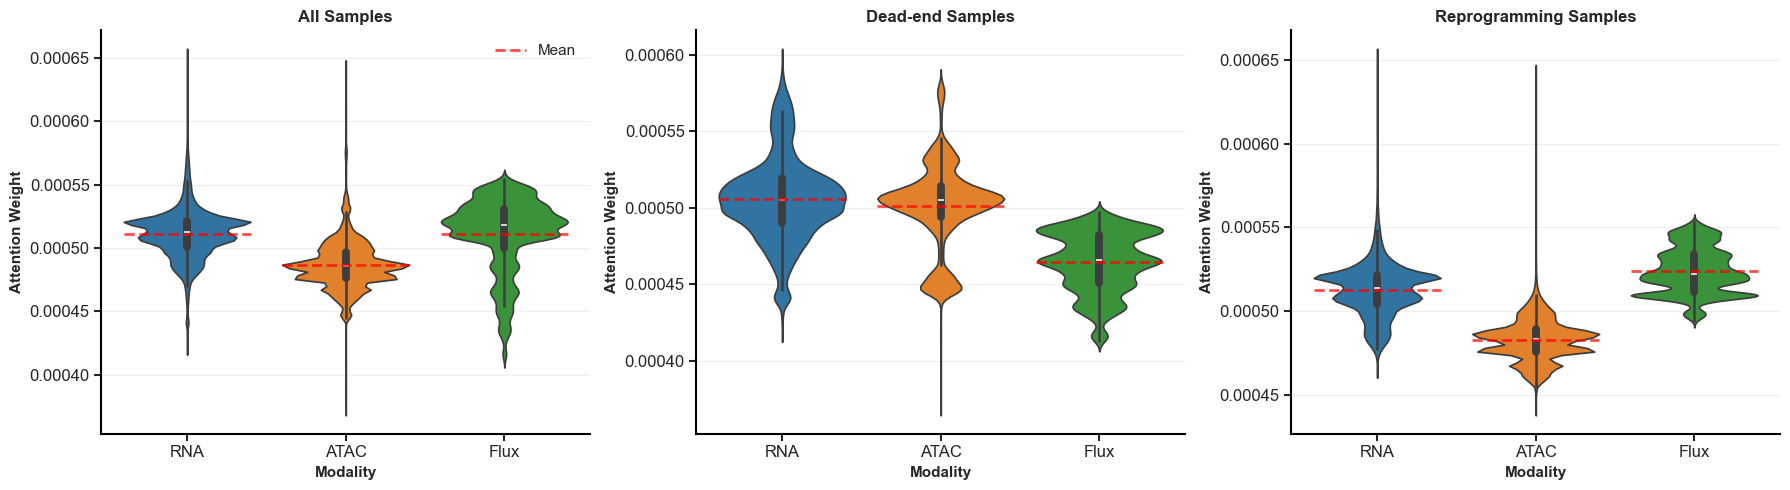

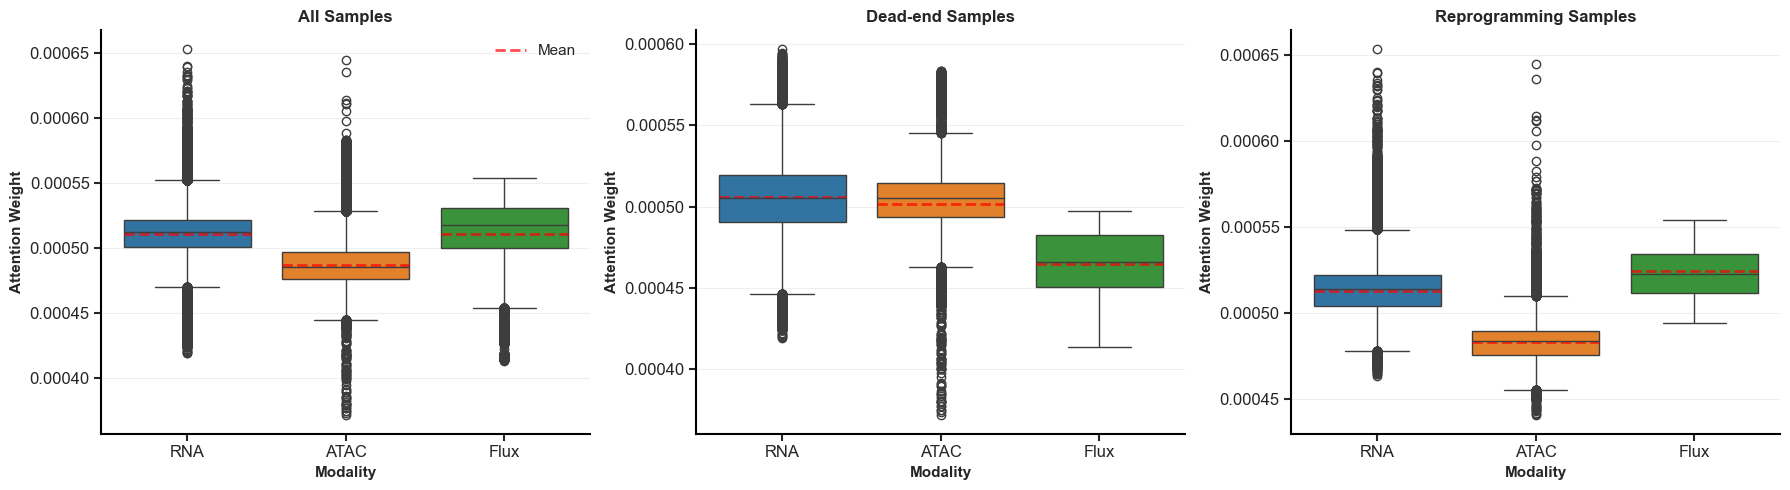

In [17]:
fig = viz.plot_att_weights_distribution(cls_layer_attentions_all_avg, cls_layer_attentions_dead_end_avg, cls_layer_attentions_reprogramming_avg, feature_names=feature_names, print_means=True)
save_fig_as_pdf(fig, os.path.join(analysis_folder, 'attention_weights_cls_distribution.pdf'))
fig = viz.plot_att_weights_distribution(cls_layer_attentions_all_avg, cls_layer_attentions_dead_end_avg, cls_layer_attentions_reprogramming_avg, feature_names=feature_names, plot_type='box')

In [18]:
top_n_print = 5+1
# att.print_top_features(rollout_attention_all[:, :945], feature_names[:945], modality='RNA', top_n=top_n_print) # RNA
# att.print_top_features(rollout_attention_all[:, 945:945+884], feature_names[945:945+884], modality='ATAC', top_n=top_n_print) # ATAC
# att.print_top_features(rollout_attention_all[:, 945+884:], feature_names[945+884:], modality='Flux', top_n=top_n_print) # Flux

top_n_get = None
fi_att_rna = att.get_top_features(rollout_attention_all[:, :945], feature_names[:945], modality='RNA', top_n=top_n_get) # RNA
fi_att_atac = att.get_top_features(rollout_attention_all[:, 945:945+884], feature_names[945:945+884], modality='ATAC', top_n=top_n_get) # ATAC
fi_att_flux = att.get_top_features(rollout_attention_all[:, 945+884:], feature_names[945+884:], modality='Flux', top_n=top_n_get) # Flux

fi_att_rna_de = att.get_top_features(rollout_attention_dead_end[:, :945], feature_names[:945], modality='RNA', top_n=top_n_get) # RNA
fi_att_atac_de = att.get_top_features(rollout_attention_dead_end[:, 945:945+884], feature_names[945:945+884], modality='ATAC', top_n=top_n_get) # ATAC
fi_att_flux_de = att.get_top_features(rollout_attention_dead_end[:, 945+884:], feature_names[945+884:], modality='Flux', top_n=top_n_get) # Flux

fi_att_rna_re = att.get_top_features(rollout_attention_reprogramming[:, :945], feature_names[:945], modality='RNA', top_n=top_n_get) # RNA
fi_att_atac_re = att.get_top_features(rollout_attention_reprogramming[:, 945:945+884], feature_names[945:945+884], modality='ATAC', top_n=top_n_get) # ATAC
fi_att_flux_re = att.get_top_features(rollout_attention_reprogramming[:, 945+884:], feature_names[945+884:], modality='Flux', top_n=top_n_get) # Flux


Metrics summary (mean ± std) for each model and MLM status:
| Model               | with_without_MLM   | AUC             | Precision       | Recall          | F1              | Accuracy        | Specificity     |   n_samples |   n_samples |
|---------------------|--------------------|-----------------|-----------------|-----------------|-----------------|-----------------|-----------------|-------------|-------------|
| Multi (With MLM)    | With MLM           | 0.9265 ± 0.0115 | 0.9178 ± 0.0162 | 0.9318 ± 0.0188 | 0.9245 ± 0.0079 | 0.8943 ± 0.0107 | 0.8095 ± 0.0430 |        2110 |        2110 |
| Multi (Without MLM) | Without MLM        | 0.8901 ± 0.0176 | 0.8748 ± 0.0204 | 0.9024 ± 0.0234 | 0.8881 ± 0.0145 | 0.8422 ± 0.0204 | 0.7055 ± 0.0536 |        2110 |        2110 |
| RNA (With MLM)      | With MLM           | 0.9233 ± 0.0154 | 0.8972 ± 0.0132 | 0.9341 ± 0.0275 | 0.9149 ± 0.0110 | 0.8795 ± 0.0140 | 0.7550 ± 0.0387 |        2008 |        2008 |
| RNA (Without MLM)   | Without MLM

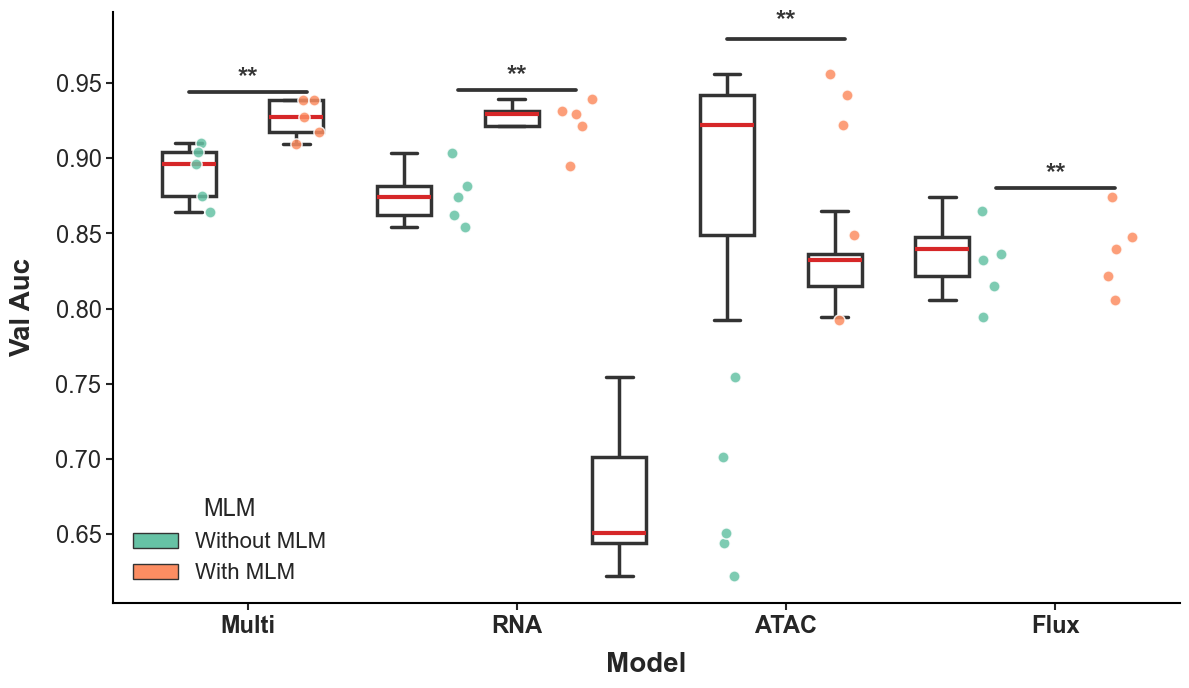

In [ ]:
from scipy.stats import mannwhitneyu, ttest_rel, wilcoxon

def plot_mlm_comparison(
    metric='val_auc',
    combination='all_samples',
    test='mannwhitney',  # Options: 'mannwhitney', 'ttest', 'wilcoxon'
    beautiful_palette=None,
    all_in_one=False,    # If True, plot all models in one plot
    data_dict=None,      # Optional: provide data as dictionary instead of reading from CSV
    print_stats=False    # If True, print mean+std for each group/model
):
    if beautiful_palette is None:
        beautiful_palette = sns.color_palette("Set2", 2)
    mlm_color_map = {'Without MLM': beautiful_palette[0], 'With MLM': beautiful_palette[1]}
    
    # Load data from dictionary or CSV
    if data_dict is not None:
        data_rows = []
        for model_name, model_data in data_dict.items():
            mlm_values = model_data.get('MLM', [])
            no_mlm_values = model_data.get('No-MLM', [])
            for val in mlm_values:
                data_rows.append({
                    'model': model_name,
                    'mlm_status': 'with_mlm',
                    'with_without_mlm': 'With MLM',
                    metric: val,
                    'combination': combination
                })
            for val in no_mlm_values:
                data_rows.append({
                    'model': model_name,
                    'mlm_status': 'without_mlm',
                    'with_without_mlm': 'Without MLM',
                    metric: val,
                    'combination': combination
                })
        df = pd.DataFrame(data_rows)
    else:
        df = pd.read_csv('com/metrics/final_results.csv')
        df = df[df['combination'] == combination]
        # Add 'with_without_mlm' column for clarity ('mlm_status' already exists)
        df['with_without_mlm'] = df['mlm_status'].map({'with_mlm': 'With MLM', 'without_mlm': 'Without MLM'})

    models = ['Multi', 'RNA', 'ATAC', 'Flux']
    extended_models = []
    for m in models:
        extended_models.append(m + " (With MLM)")
        extended_models.append(m + " (Without MLM)")
    n_rows = len(extended_models)

    # Print stats if requested
    if print_stats:
        header_metrics = [
            "AUC", "Precision", "Recall", "F1", "Accuracy", "Specificity", "n_samples", "with_without_MLM"
        ]
        display_metrics = [
            "val_auc", "precision", "recall", "f1", "accuracy", "specificity"
        ]
        stats_rows = []
        for model in models:
            for mlm_status, mlm_text in zip(["with_mlm", "without_mlm"], ["With MLM", "Without MLM"]):
                this_label = f"{model} ({mlm_text})"
                row = {"Model": this_label, "with_without_MLM": mlm_text}
                subdf = df[(df['model'] == model) & (df['mlm_status'] == mlm_status)]
                for show_metric, col_metric in zip(header_metrics[:-2], display_metrics):
                    vals = subdf[col_metric].values if col_metric in subdf.columns else np.array([])
                    row[show_metric] = f"{np.mean(vals):.4f} ± {np.std(vals):.4f}" if len(vals) > 0 else "-"
                # SUM n_samples, do not take average
                if "n_samples" in subdf.columns and len(subdf) > 0:
                    row["n_samples"] = int(subdf["n_samples"].sum())
                else:
                    row["n_samples"] = len(subdf)
                stats_rows.append(row)
        table_df = pd.DataFrame(stats_rows)
        col_order = ["Model", "with_without_MLM"] + header_metrics[:-1] + ["n_samples"]
        table_df = table_df[col_order]
        from tabulate import tabulate
        print("Metrics summary (mean ± std) for each model and MLM status:")
        print(tabulate(table_df, headers="keys", tablefmt="github", showindex=False))
        print("\n")

    wider_box_width = 0.5  # Make boxes thinner for more separation

    mlm_gap = 0.10  # This determines the gap between boxes; larger is wider spacing

    # This is the spacing between the *pairs* of boxes for each model
    model_gap_width = 2.5

    if all_in_one:
        plot_df = []
        stat_results = {}
        for model in models:
            data = df[df['model'] == model]
            with_mlm = data[data['mlm_status'] == 'with_mlm'][metric].values
            without_mlm = data[data['mlm_status'] == 'without_mlm'][metric].values
            n_with = len(with_mlm)
            n_without = len(without_mlm)
            plot_df.append(pd.DataFrame({
                metric: np.concatenate([without_mlm, with_mlm]),
                'MLM': ['Without MLM']*n_without + ['With MLM']*n_with,
                'with_without_mlm': ['Without MLM']*n_without + ['With MLM']*n_with,
                'Model': [model]*(n_without+n_with)
            }))
            # Statistical test selection
            if test == 'mannwhitney':
                stat, pval = mannwhitneyu(with_mlm, without_mlm, alternative='two-sided')
            elif test == 'ttest':
                stat, pval = ttest_rel(with_mlm, without_mlm)
            elif test == 'wilcoxon':
                if len(with_mlm) == len(without_mlm):
                    stat, pval = wilcoxon(with_mlm, without_mlm)
                else:
                    stat, pval = np.nan, np.nan
            else:
                raise ValueError("test must be one of: 'mannwhitney', 'ttest', 'wilcoxon'")
            stat_results[model] = (stat, pval)
        plot_df = pd.concat(plot_df, ignore_index=True)

        # Compute positions for each box, and assign model/group => x
        pos_map = {}
        box_positions = []
        xticks = []
        for i, model in enumerate(models):
            left = i * model_gap_width
            right = left + 1 + mlm_gap
            pos_map[(model, 'Without MLM')] = left
            pos_map[(model, 'With MLM')] = right
            # xticks halfway between left and right
            xticks.append((left + right)/2)
            box_positions += [left, right]
        # Keep each box/dot/group at correct coordinate, so boxes, dots, bars all align

        fig, ax = plt.subplots(figsize=(max(8, int((2.5*len(models))*model_gap_width/2)), 7))

        # Draw boxes for all positions at once for correct alignment
        yvalues = []
        xpos = []
        group_colors = []
        groups_labels = []
        for model in models:
            for group in ['Without MLM', 'With MLM']:
                x = pos_map[(model, group)]
                y = plot_df[(plot_df['Model'] == model) & (plot_df['MLM'] == group)][metric].values
                if len(y) == 0:
                    continue
                yvalues.append(y)
                xpos.append(x)
                group_colors.append(mlm_color_map[group])
                groups_labels.append(group)

        # Custom loop to plot boxplots with explicit positions, so they align
        for idx, y in enumerate(yvalues):
            sns.boxplot(
                x=[xpos[idx]]*len(y), y=y, width=wider_box_width, showcaps=True,
                boxprops={'facecolor':'white', 'edgecolor':'#333', 'linewidth':2.5},
                showfliers=False, whiskerprops={'linewidth':2.5, 'color':'#333'},
                medianprops={'color':'#d62728', 'linewidth':3},
                capprops={'linewidth':2.5, 'color':'#333'},
                palette=[group_colors[idx]],
                ax=ax
            )

        # Plot the dots at same x positions
        for idx, y in enumerate(yvalues):
            dots_x = np.random.normal(xpos[idx], 0.09, size=len(y))
            ax.scatter(
                dots_x, y, alpha=0.85, color=group_colors[idx], s=65, zorder=10,
                edgecolor='white', linewidth=1.1
            )

        # Add significance bars/stats at correct x
        for i, model in enumerate(models):
            left = pos_map[(model, 'Without MLM')]
            right = pos_map[(model, 'With MLM')]
            stat, pval = stat_results[model]
            sig = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else 'n.s.'
            y_max = plot_df[plot_df['Model'] == model][metric].max()
            y_min = plot_df[plot_df['Model'] == model][metric].min()
            y_sig = y_max + 0.07*(y_max-y_min) if y_max > y_min else y_max + 0.05
            ax.plot([left, right], [y_sig, y_sig], color='#333', linewidth=2.7, zorder=20)
            ax.text(
                (left + right)/2, y_sig + 0.01*(y_max-y_min),
                f'{sig}',
                ha='center', va='bottom', fontsize=19, fontweight='bold', color='#333'
            )

        ax.set_xticks(xticks)
        ax.set_xticklabels(models, fontsize=18, fontweight='semibold')
        ax.set_xlabel("Model", fontsize=20, labelpad=10)
        ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=20, labelpad=14)
        ax.tick_params(axis='both', which='major', labelsize=17)
        # Custom legend
        from matplotlib.patches import Patch
        handles = [Patch(facecolor=mlm_color_map['Without MLM'], edgecolor='#333', label='Without MLM'),
                   Patch(facecolor=mlm_color_map['With MLM'], edgecolor='#333', label='With MLM')]
        ax.legend(handles=handles, title='MLM', fontsize=16, title_fontsize=17, loc='lower left')
        fig.patch.set_facecolor('white')
        plt.tight_layout()
        return fig

    else:
        nrows, ncols = 2, 2
        fig, axes = plt.subplots(nrows, ncols, figsize=(8.5*ncols, 7*nrows), sharey=False)
        axes = axes.flatten()

        for idx, model in enumerate(models):
            data = df[df['model'] == model]
            with_mlm = data[data['mlm_status'] == 'with_mlm'][metric].values
            without_mlm = data[data['mlm_status'] == 'without_mlm'][metric].values

            plot_df = pd.DataFrame({
                metric: np.concatenate([without_mlm, with_mlm]),
                'MLM': ['Without MLM']*len(without_mlm) + ['With MLM']*len(with_mlm),
                'with_without_mlm': ['Without MLM']*len(without_mlm) + ['With MLM']*len(with_mlm)
            })

            ax = axes[idx]

            # For 2x2, keep as before but can slightly spread boxes apart
            local_mlm_gap = mlm_gap * 1.5  # slightly more
            box_positions = [0, 1 + local_mlm_gap]
            for j, group in enumerate(['Without MLM', 'With MLM']):
                y = plot_df[plot_df['MLM'] == group][metric].values
                if len(y) == 0:
                    continue
                sns.boxplot(
                    x=[box_positions[j]]*len(y), y=y, width=wider_box_width, showcaps=True,
                    boxprops={'facecolor':'white', 'edgecolor':'#333', 'linewidth':2.5},
                    showfliers=False, whiskerprops={'linewidth':2.5, 'color':'#333'},
                    medianprops={'color':'#d62728', 'linewidth':3},
                    capprops={'linewidth':2.5, 'color':'#333'},
                    palette=[mlm_color_map[group]],
                    ax=ax
                )
                # Individual dots with jitter
                x_dot = np.random.normal(box_positions[j], 0.09, size=len(y))
                ax.scatter(
                    x_dot, y, alpha=0.85, color=mlm_color_map[group], s=65, zorder=10,
                    edgecolor='white', linewidth=1.1
                )

            ax.set_title(model, fontsize=23, fontweight='bold', pad=16)
            if idx % ncols == 0:
                ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=20, labelpad=14)
            else:
                ax.set_ylabel("")
            ax.set_xlabel("")

            # Statistical test selection
            if test == 'mannwhitney':
                stat, pval = mannwhitneyu(with_mlm, without_mlm, alternative='two-sided')
            elif test == 'ttest':
                stat, pval = ttest_rel(with_mlm, without_mlm, equal_var=False)
            elif test == 'wilcoxon':
                if len(with_mlm) == len(without_mlm):
                    stat, pval = wilcoxon(with_mlm, without_mlm)
                else:
                    stat, pval = np.nan, np.nan
            else:
                raise ValueError("test must be one of: 'mannwhitney', 'ttest', 'wilcoxon'")

            sig = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else 'n.s.'
            y_max = plot_df[metric].max()
            y_min = plot_df[metric].min()
            y_sig = y_max + 0.07*(y_max-y_min) if y_max > y_min else y_max + 0.05
            ax.plot([box_positions[0], box_positions[1]], [y_sig, y_sig], color='#333', linewidth=2.7, zorder=20)
            ax.text(
                (box_positions[0] + box_positions[1])/2, y_sig + 0.01*(y_max-y_min),
                f'{sig}\np={pval:.3g}',
                ha='center', va='bottom', fontsize=19, fontweight='bold', color='#333'
            )

            ax.tick_params(axis='both', which='major', labelsize=17)
            ax.set_xticks(box_positions)
            ax.set_xticklabels(['Without MLM', 'With MLM'], fontsize=18, fontweight='semibold')

        for j in range(len(models), nrows*ncols):
            fig.delaxes(axes[j])

        plt.tight_layout(h_pad=3.5, w_pad=4.0)
        fig.patch.set_facecolor('white')
        return fig


fig = plot_mlm_comparison('val_auc', 'all_samples', test='ttest', all_in_one=True, data_dict=None, print_stats=True)
save_fig_as_pdf(fig, os.path.join(analysis_folder, 'mlm_comparison.pdf'))
plt.show()

In [ ]:
def create_combined_feature_dataframe(fi_shift_rna, fi_shift_atac, fi_shift_flux,
                                      fi_att_rna, fi_att_atac, fi_att_flux,
                                      df_rna_degs=None, df_atac_degs=None, df_flux_degs=None,
                                      remove_batch=True):
    
    def process_modality(shift_list, att_list, degs_df, modality_name):
        shift_df = pd.DataFrame(shift_list, columns=["feature", "importance_shift"]).reset_index()
        shift_df.rename(columns={"index": "rank_shift_in_modal"}, inplace=True)
        shift_df["rank_shift_in_modal"] += 1
        
        att_df = pd.DataFrame(att_list, columns=["feature", "importance_att"]).reset_index()
        att_df.rename(columns={"index": "rank_att_in_modal"}, inplace=True)
        att_df["rank_att_in_modal"] += 1
        
        combined_df = pd.merge(shift_df, att_df, on="feature", how="outer")
        
        if degs_df is not None:
            combined_df = pd.merge(combined_df, degs_df, on="feature", how="left")
        
        combined_df["modality"] = modality_name
        
        return combined_df
    
    rna_df = process_modality(fi_shift_rna, fi_att_rna, df_rna_degs, "RNA")
    atac_df = process_modality(fi_shift_atac, fi_att_atac, df_atac_degs, "ATAC")
    flux_df = process_modality(fi_shift_flux, fi_att_flux, df_flux_degs, "Flux")
    
    all_features_df = pd.concat([rna_df, atac_df, flux_df], ignore_index=True)
    
    if remove_batch:
        all_features_df = all_features_df[~all_features_df["feature"].str.contains("batch", na=False)]
    
    max_rank_modal = max(all_features_df["rank_att_in_modal"].max(), all_features_df["rank_shift_in_modal"].max())
    all_features_df[["rank_att_in_modal", "rank_shift_in_modal"]] = all_features_df[["rank_att_in_modal", "rank_shift_in_modal"]].fillna(max_rank_modal + 1)
    all_features_df[["rank_att_in_modal", "rank_shift_in_modal"]] = all_features_df[["rank_att_in_modal", "rank_shift_in_modal"]].astype("int32")
    
    all_features_df[["importance_att", "importance_shift"]] = all_features_df[["importance_att", "importance_shift"]].fillna(0).astype("float64")
    
    all_features_df["rank_shift"] = all_features_df["importance_shift"].rank(ascending=False, method="first").astype("int32")
    all_features_df["rank_att"] = all_features_df["importance_att"].rank(ascending=False, method="first").astype("int32")
    
    all_features_df["mean_rank"] = all_features_df[["rank_att", "rank_shift"]].mean(axis=1)
    
    top_th = int(all_features_df.shape[0] * 0.1) + 1
    all_features_df["top_10_pct"] = all_features_df.apply(
        lambda row: "both" if row["rank_shift"] <= top_th and row["rank_att"] <= top_th else 
        ("shift" if row["rank_shift"] <= top_th else ("att" if row["rank_att"] <= top_th else "None")),
        axis=1
    )
    
    float_cols = [col for col in all_features_df.columns if col.startswith(('log_fc', 'mean_', 'std_', 'pval_'))]
    if float_cols:
        all_features_df[float_cols] = all_features_df[float_cols].round(6)
    
    all_features_df["importance_att"] = all_features_df["importance_att"].round(6)
    all_features_df["importance_shift"] = all_features_df["importance_shift"].round(6)
    all_features_df = all_features_df.sort_values(by="mean_rank", ascending=True)
    
    all_features_df = all_features_df[['mean_rank', 'feature', 'rank_shift', 'rank_att', 'rank_shift_in_modal', 
        'rank_att_in_modal', 'modality', 'importance_shift', 'importance_att', 'top_10_pct', 
        'mean_de', 'mean_re', 'std_de', 'std_re', 'pval', 'pval_adj', 'log_fc', 'group',
        'pval_adj_log', 'mean_diff', 'pathway', 'module']]
    
    return all_features_df

df_features = create_combined_feature_dataframe(fi_shift_rna, fi_shift_atac,
                                        fi_shift_flux, fi_att_rna, fi_att_atac, fi_att_flux,
                                        df_rna_degs, df_atac_degs, df_flux_degs)

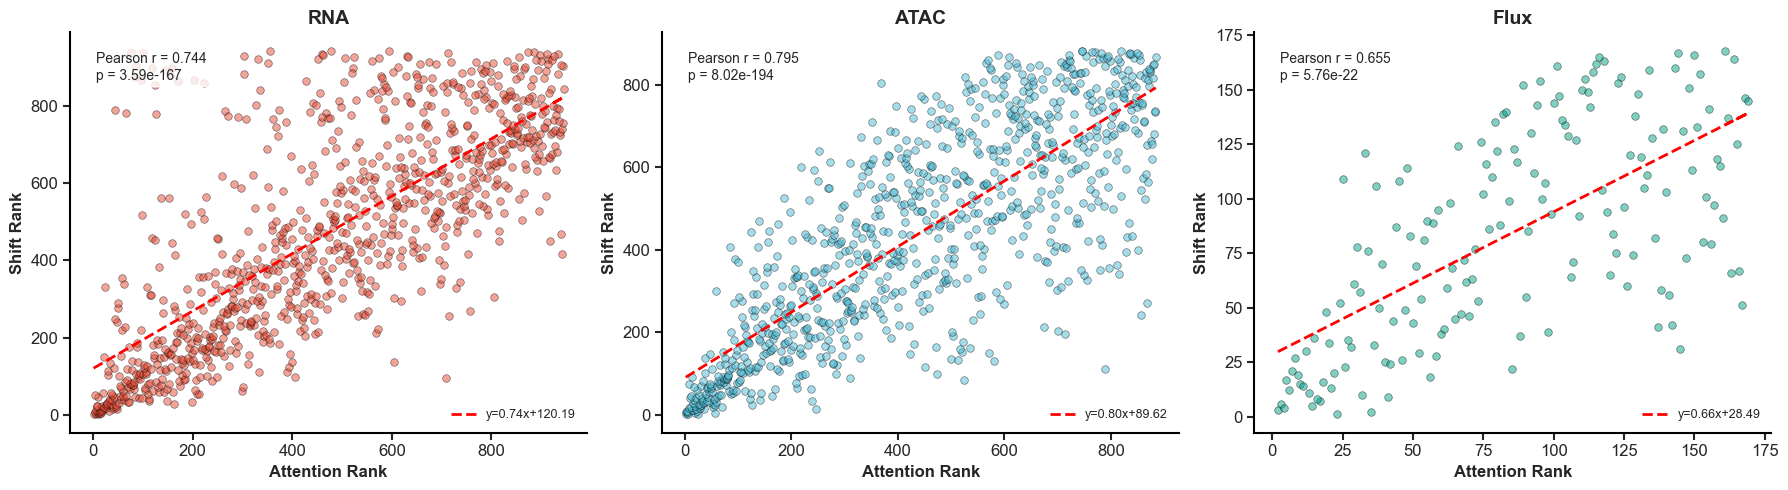

In [ ]:
def plot_rank_correlation(rna_df, atac_df, flux_df, figsize=(18, 5), save_path=None):
    from scipy.stats import pearsonr
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    dfs = [rna_df, atac_df, flux_df]
    titles = ['RNA', 'ATAC', 'Flux']
    colors = ['#E64B35', '#4DBBD5', '#00A087']
    
    for idx, (df, title, color) in enumerate(zip(dfs, titles, colors)):
        ax = axes[idx]
        
        df_clean = df[['rank_att_in_modal', 'rank_shift_in_modal']].dropna()
        x = df_clean['rank_att_in_modal']
        y = df_clean['rank_shift_in_modal']
        
        ax.scatter(x, y, alpha=0.5, s=30, color=color, edgecolors='black', linewidth=0.5, rasterized=True)
        
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        ax.plot(x, p(x), "r--", linewidth=2, label=f'y={z[0]:.2f}x+{z[1]:.2f}')
        
        pearson_corr, pearson_p = pearsonr(x, y)
        
        textstr = f'Pearson r = {pearson_corr:.3f}\np = {pearson_p:.2e}'
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_xlabel('Attention Rank', fontsize=12, fontweight='bold')
        ax.set_ylabel('Shift Rank', fontsize=12, fontweight='bold')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        # ax.grid(True, alpha=0.3, linestyle='--')
        
        # max_val = max(x.max(), y.max())
        # ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=1)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig
rna_combined_df = df_features[df_features.modality == "RNA"]
atac_combined_df = df_features[df_features.modality == "ATAC"]
flux_combined_df = df_features[df_features.modality == "Flux"]
fig = plot_rank_correlation(rna_combined_df, atac_combined_df, flux_combined_df)
plt.show()

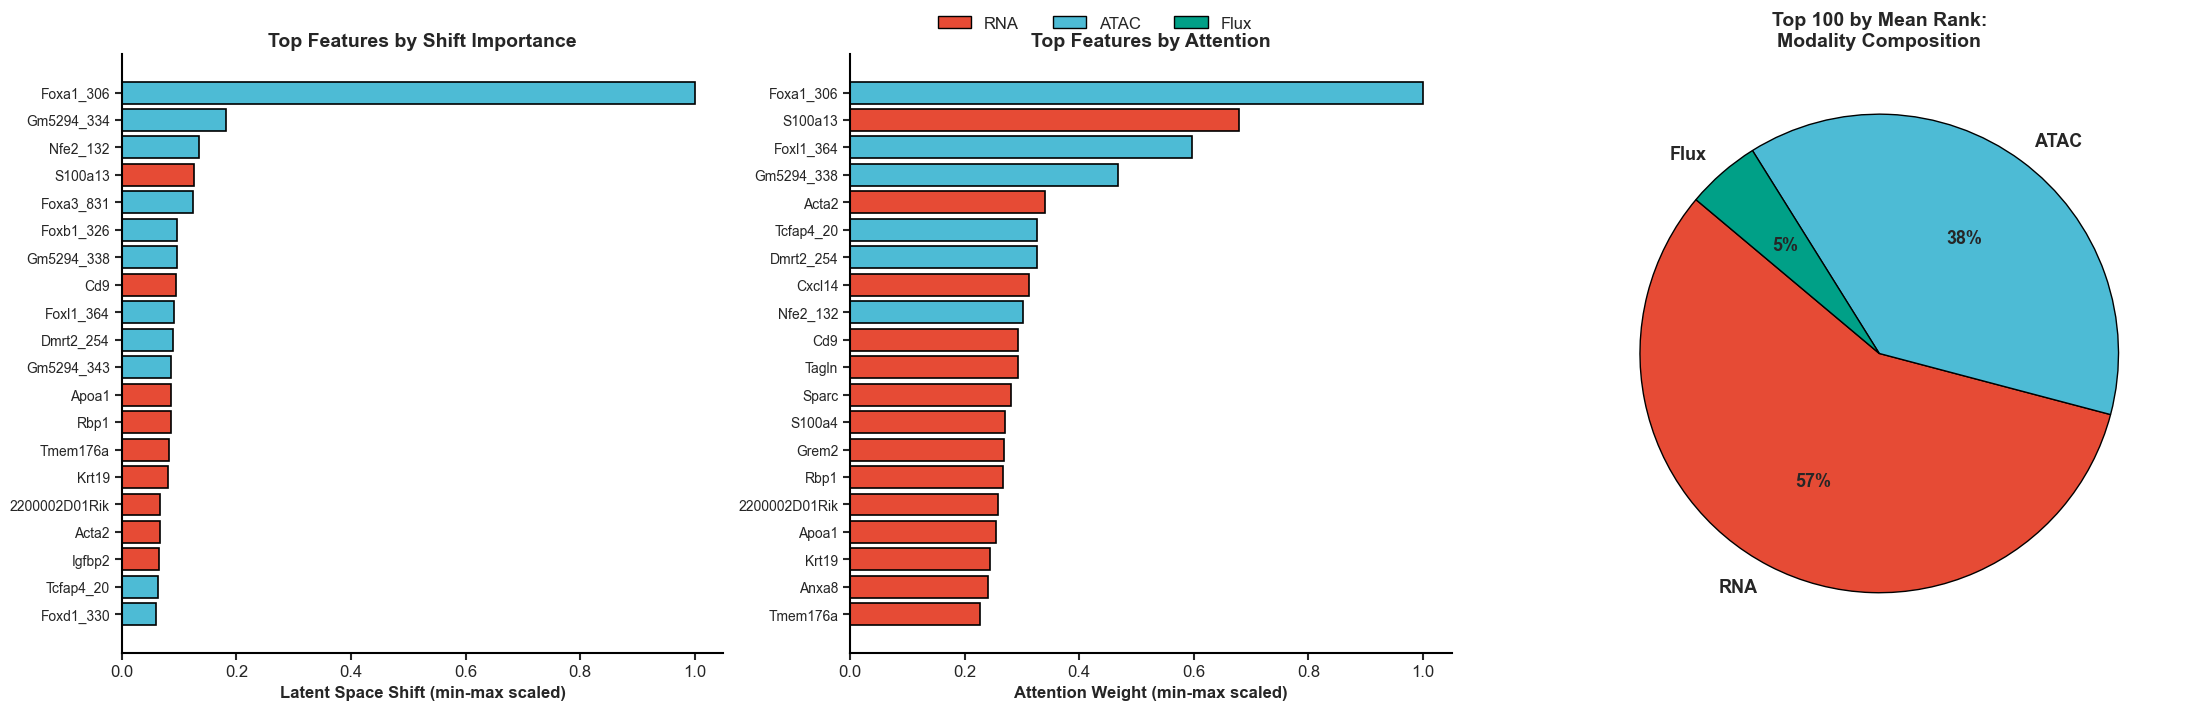

In [22]:
def plot_top_features_shift_attention(df_features, top_n=20, top_n_pie=100, print_top_features=False):
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.patches import Patch

    # Min-max scale importance columns
    df_features = df_features.copy()
    for col in ['importance_shift', 'importance_att']:
        min_val = df_features[col].min()
        max_val = df_features[col].max()
        if max_val > min_val:
            df_features[col + '_norm'] = (df_features[col] - min_val) / (max_val - min_val)
        else:
            df_features[col + '_norm'] = 0.0

    shift_top = df_features.nlargest(top_n, 'importance_shift')[['feature', 'importance_shift_norm', 'modality']]
    att_top = df_features.nlargest(top_n, 'importance_att')[['feature', 'importance_att_norm', 'modality']]
    mean_rank_top_for_pie = df_features.nsmallest(top_n_pie, 'mean_rank')[['feature', 'mean_rank', 'modality']]

    # Add for mean rank display: get the actual ranks (by shift, att, mean)
    df_features['rank_shift'] = df_features['importance_shift'].rank(ascending=False, method='min')
    df_features['rank_att'] = df_features['importance_att'].rank(ascending=False, method='min')
    df_features['rank_mean'] = df_features['mean_rank'].rank(ascending=True, method='min')
    mean_rank_top = df_features.nsmallest(top_n, 'mean_rank')[['feature', 'mean_rank', 'modality', 'rank_shift', 'rank_att', 'rank_mean']].copy()

    color_map = {'RNA': '#E64B35', 'ATAC': '#4DBBD5', 'Flux': '#00A087'}
    pie_labels = ['RNA', 'ATAC', 'Flux']

    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    ax1, ax2, ax3 = axes

    # Plot 1: Top by Shift Importance
    shift_features = shift_top['feature'].tolist()
    shift_values = shift_top['importance_shift_norm'].tolist()
    shift_colors = [color_map[m] for m in shift_top['modality']]
    y_pos_shift = np.arange(len(shift_features))
    ax1.barh(y_pos_shift, shift_values, color=shift_colors, edgecolor='black', linewidth=1.2)
    ax1.set_yticks(y_pos_shift)
    ax1.set_yticklabels(shift_features, fontsize=10)
    ax1.invert_yaxis()
    ax1.set_xlabel('Latent Space Shift (min-max scaled)', fontsize=12, fontweight='bold')
    ax1.set_title('Top Features by Shift Importance', fontsize=14, fontweight='bold')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # Plot 2: Top by Attention
    att_features = att_top['feature'].tolist()
    att_values = att_top['importance_att_norm'].tolist()
    att_colors = [color_map[m] for m in att_top['modality']]
    y_pos_att = np.arange(len(att_features))
    ax2.barh(y_pos_att, att_values, color=att_colors, edgecolor='black', linewidth=1.2)
    ax2.set_yticks(y_pos_att)
    ax2.set_yticklabels(att_features, fontsize=10)
    ax2.invert_yaxis()
    ax2.set_xlabel('Attention Weight (min-max scaled)', fontsize=12, fontweight='bold')
    ax2.set_title('Top Features by Attention', fontsize=14, fontweight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # Plot 3: Pie chart of modalities in top N mean-rank features
    modality_counts = mean_rank_top_for_pie['modality'].value_counts()
    pie_counts = [modality_counts.get(label, 0) for label in pie_labels]
    pie_colors = [color_map[label] for label in pie_labels]

    wedges, texts, autotexts = ax3.pie(
        pie_counts,
        labels=pie_labels,
        colors=pie_colors,
        autopct='%1.0f%%',
        startangle=140,
        wedgeprops=dict(edgecolor='black'),
        textprops={'fontsize': 13, 'weight': 'bold'}
    )
    ax3.set_title(f'Top {top_n_pie} by Mean Rank:\nModality Composition', fontsize=14, fontweight='bold')

    # Print top 10 features of each modality from the top N by mean rank,
    # and ALSO show actual shift/att/mean rank for each (in sorted order).
    if print_top_features:
        print(f"\nTop features (up to 10 per modality) among the top {top_n_pie} by mean rank:")
        for modality in pie_labels:
            subset = mean_rank_top_for_pie[mean_rank_top_for_pie['modality'] == modality] \
                .merge(df_features[['feature', 'rank_shift', 'rank_att', 'rank_mean']], on='feature') \
                .sort_values('mean_rank').head(10)
            if not subset.empty:
                print(f"\n{modality} (count in top {top_n_pie}: {subset.shape[0]})")
                for _, row in subset.iterrows():
                    print(f"  Feature: {row['feature']} (Mean rank: {row['mean_rank']:.1f}, " +
                        f"Shift rank: {int(row['rank_shift'])}, Attention rank: {int(row['rank_att'])}, Mean-rank pos: {int(row['rank_mean'])})")
            else:
                print(f"\n{modality}: No features in top {top_n_pie} by mean rank.")

    legend_elements = [
        Patch(facecolor='#E64B35', edgecolor='black', label='RNA'),
        Patch(facecolor='#4DBBD5', edgecolor='black', label='ATAC'),
        Patch(facecolor='#00A087', edgecolor='black', label='Flux')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False, fontsize=12)

    # (OPTIONAL) You could instead show table of these ranks elsewhere as a figure, if desired.

    plt.tight_layout()
    return fig

fig = plot_top_features_shift_attention(df_features, print_top_features=False)
save_fig_as_pdf(fig, os.path.join(analysis_folder, 'top_features_shift_attention.pdf'))

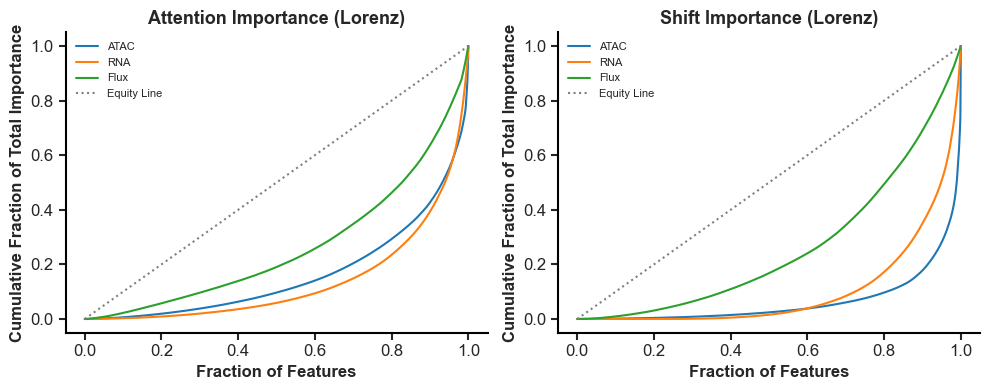

In [23]:
def plot_modality_importance_pareto(df_features, importance_cols=("importance_att", "importance_shift"),
                                    modality_col="modality", title1="Attention Importance (Lorenz)", title2="Shift Importance (Lorenz)"):
    """
    Plot Lorenz-like (Pareto) curves for feature importance values split by modality.
    Uses df_features only.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    skip_features = {'batch_rna', 'batch_atac', 'batch_flux'}
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    modalities = [m for m in df_features[modality_col].unique() if pd.notnull(m)]

    def compute_curve(scores):
        norm_scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
        sorted_scores = np.sort(norm_scores)
        cum_scores = np.cumsum(sorted_scores)
        total = cum_scores[-1]
        frac = cum_scores / total if total != 0 else cum_scores
        x = np.insert(np.arange(1, len(sorted_scores)+1) / len(sorted_scores), 0, 0)
        frac = np.insert(frac, 0, 0)
        return x, frac

    # Attention-based importance
    for modality in modalities:
        sub = df_features[(df_features[modality_col] == modality) & (~df_features["feature"].isin(skip_features))]
        scores = sub[importance_cols[0]].values
        if len(scores) == 0:
            continue
        x, frac = compute_curve(scores)
        ax1.plot(x, frac, label=str(modality))
    ax1.plot([0, 1], [0, 1], ls=":", color="gray", label="Equity Line")
    ax1.set_xlabel("Fraction of Features", fontsize=12)
    ax1.set_ylabel("Cumulative Fraction of Total Importance", fontsize=12)
    ax1.set_title(title1, fontsize=13)
    ax1.legend(fontsize=8)

    # Shift-based importance
    for modality in modalities:
        sub = df_features[(df_features[modality_col] == modality) & (~df_features["feature"].isin(skip_features))]
        scores = sub[importance_cols[1]].values
        if len(scores) == 0:
            continue
        x, frac = compute_curve(scores)
        ax2.plot(x, frac, label=str(modality))
    ax2.plot([0, 1], [0, 1], ls=":", color="gray", label="Equity Line")
    ax2.set_xlabel("Fraction of Features", fontsize=12)
    ax2.set_ylabel("Cumulative Fraction of Total Importance", fontsize=12)
    ax2.set_title(title2, fontsize=13)
    ax2.legend(fontsize=8)

    plt.tight_layout()
    return fig

fig = plot_modality_importance_pareto(df_features)
save_fig_as_pdf(fig, os.path.join(analysis_folder, 'modality_importance_pareto.pdf'))
plt.show()


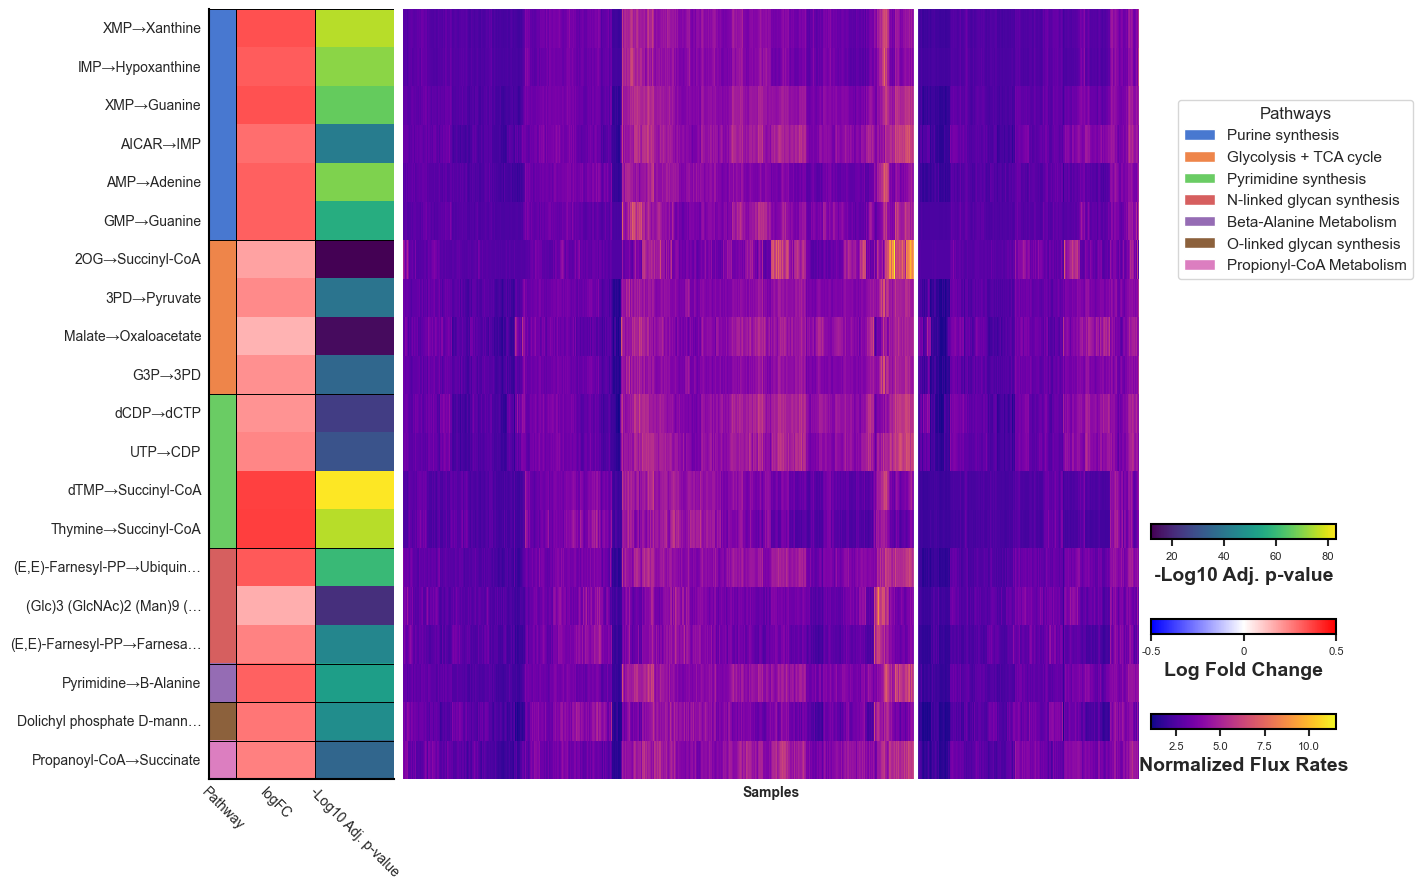

In [ ]:
def plot_flux_heatmap(df_features, top_n=30, metric='mean_rank'):

    # -------------------------------
    # 1. Select top 30 reactions based on mean_rank
    # -------------------------------
    flux_combined_df = df_features[df_features.modality == "Flux"]

    top30_df = flux_combined_df[flux_combined_df['group'] == 'dead-end'].sort_values(metric).head(top_n).copy()
    top30_df = flux_combined_df.sort_values(metric).head(top_n).copy()
    top30_df = top30_df[~top30_df['feature'].str.contains('batch_flux')]

    # -------------------------------
    # 2. Sort reactions by pathway frequency
    # -------------------------------
    pathway_counts = top30_df['pathway'].value_counts()
    top30_df['pathway_count'] = top30_df['pathway'].map(pathway_counts)
    top30_df.sort_values(['pathway_count', 'pathway'], ascending=[False, True], inplace=True)
    features_order = top30_df['feature'].tolist()

    # -------------------------------
    # 3. Subset flux data for the selected reactions
    # -------------------------------
    # (Assuming adata_Flux_labelled has reactions as columns.)
    heatmap_data = adata_Flux_labelled[features_order].T  # rows: reactions, cols: samples

    # -------------------------------
    # 4. Reorder samples: first reprogramming then dead-end; cluster within groups
    # -------------------------------
    rp_samples = flux_labels[flux_labels == 'reprogramming'].index.tolist()
    de_samples = flux_labels[flux_labels == 'dead-end'].index.tolist()

    if len(rp_samples) > 1:
        rp_data = heatmap_data[rp_samples]
        Z_rp = linkage(rp_data.T, method='average', metric='euclidean')
        ordered_idx_rp = leaves_list(Z_rp)
        ordered_rp = list(reversed(rp_data.columns[ordered_idx_rp]))
    else:
        ordered_rp = rp_samples

    if len(de_samples) > 1:
        de_data = heatmap_data[de_samples]
        Z_de = linkage(de_data.T, method='average', metric='euclidean')
        ordered_idx_de = leaves_list(Z_de)
        ordered_de = list(de_data.columns[ordered_idx_de])
    else:
        ordered_de = de_samples

    ordered_samples = ordered_rp + ordered_de
    heatmap_data = heatmap_data[ordered_samples]
    flux_labels_ordered = flux_labels.loc[ordered_samples].str.capitalize()  # Capitalize group names

    # -------------------------------
    # 5. Define color palettes for annotations
    # -------------------------------
    group_palette = sns.color_palette("Set1", 2)
    sample_color_dict = {'Reprogramming': group_palette[0], 'Dead-end': group_palette[1]}

    unique_pathways = top30_df['pathway'].unique()
    pathway_palette = sns.color_palette("muted", len(unique_pathways))
    pathway_color_dict = dict(zip(unique_pathways, pathway_palette))
    reaction_pathway_series = top30_df.set_index('feature').loc[features_order, 'pathway']
    reaction_pathway_colors = reaction_pathway_series.map(pathway_color_dict)

    log_fc_values = top30_df.set_index('feature').loc[features_order, 'log_fc']
    
    # Changed normalization: vmin=-0.5, vmax=0.5 for logFC color mapping and colorbar
    norm_logfc = mcolors.Normalize(vmin=-0.5, vmax=0.5)
    reaction_logfc_colors = log_fc_values.apply(lambda x: plt.cm.bwr(norm_logfc(x)))

    pval_series = top30_df.set_index('feature').loc[features_order, 'pval_adj_log']
    norm_pval = mcolors.Normalize(vmin=pval_series.min(), vmax=pval_series.max())
    reaction_pval_colors = pval_series.apply(lambda x: plt.cm.viridis(norm_pval(x)))

    # -------------------------------
    # 6. Truncate feature names to avoid overly long labels
    # -------------------------------
    max_length = 25
    def truncate_feature_name(name, max_length=15):
        return name if len(name) <= max_length else name[:max_length] + "…"
    truncated_features = [truncate_feature_name(feat, max_length) for feat in features_order]

    # -------------------------------
    # 7. Prepare legend handles for pathways and groups
    # -------------------------------
    pathway_legend_handles = [Patch(facecolor=pathway_color_dict[p], label=p) for p in pathway_color_dict]
    group_legend_handles   = [Patch(facecolor=sample_color_dict[label], label=label) for label in sample_color_dict]

    # -------------------------------
    # 8. Plotting with annotations (no top row)
    # -------------------------------
    fig = plt.figure(figsize=(12, 10))
    # Increase the left margin by slightly increasing the left panel’s width ratio.
    gs = gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[0.25, 1], wspace=0.02)

    # (a) Left panel: Reaction annotations
    # Three columns:
    #   Column 1: Pathway (width = 1/3)
    #   Column 2: logFC (width = 1)
    #   Column 3: -Log10 Adj. p-value (width = 1)
    ax_left = fig.add_subplot(gs[0, 0])
    n_reactions = len(features_order)
    w_pathway = 1/3    # for pathway annotation
    w_logfc   = 1      # logFC annotation width
    w_pval    = 1      # -Log10 Adj. p-value annotation width
    total_width = w_pathway + w_logfc + w_pval

    # Set extents so that row 0 (first reaction in features_order) appears at the top.
    extent_pathway = [0, w_pathway, n_reactions, 0]
    extent_logfc   = [w_pathway, w_pathway + w_logfc, n_reactions, 0]
    extent_pval    = [w_pathway + w_logfc, total_width, n_reactions, 0]

    ax_left.imshow(
        np.array([mcolors.to_rgba(reaction_pathway_colors[feat]) for feat in features_order])
        .reshape(n_reactions, 1, 4),
        aspect='auto', interpolation='none', origin='upper', extent=extent_pathway
    )
    ax_left.imshow(
        np.array([reaction_logfc_colors[feat] for feat in features_order])
        .reshape(n_reactions, 1, 4),
        aspect='auto', interpolation='none', origin='upper', extent=extent_logfc
    )
    ax_left.imshow(
        np.array([reaction_pval_colors[feat] for feat in features_order])
        .reshape(n_reactions, 1, 4),
        aspect='auto', interpolation='none', origin='upper', extent=extent_pval
    )

    # Set x-ticks at centers of each annotation column.
    xticks = [w_pathway/2, w_pathway + w_logfc/2, w_pathway + w_logfc + w_pval/2]
    ax_left.set_xticks(xticks)
    ax_left.set_xticklabels(["Pathway", "logFC", "-Log10 Adj. p-value"], fontsize=10, rotation=-45)
    ax_left.tick_params(axis='x', length=0)

    # ----- FIX: Instead of relying on the default y–tick labels (which can misalign with the annotation rows),
    # we remove them and then manually add reaction names (labels) so that each label appears in its own row.
    ax_left.set_yticks([])  # remove default ticks

    for i, label in enumerate(truncated_features):
        # Because imshow uses extent [0, n_reactions, ... 0] with origin='upper',
        # the center of row i (where i=0 is the first entry in features_order) is at:
        y_pos = i + 0.5
        ax_left.text(-0.1, y_pos, label, ha='right', va='center', fontsize=10, transform=ax_left.transData)

    # Draw borders around each annotation column.
    rect_pathway = plt.Rectangle((0, 0), w_pathway, n_reactions,
                                linewidth=0.7, edgecolor='black', facecolor='none',
                                transform=ax_left.transData)
    rect_logfc = plt.Rectangle((w_pathway, 0), w_logfc, n_reactions,
                            linewidth=0.7, edgecolor='black', facecolor='none',
                            transform=ax_left.transData)
    rect_pval = plt.Rectangle((w_pathway + w_logfc, 0), w_pval, n_reactions,
                            linewidth=0.7, edgecolor='black', facecolor='none',
                            transform=ax_left.transData)
    ax_left.add_patch(rect_pathway)
    ax_left.add_patch(rect_logfc)
    ax_left.add_patch(rect_pval)

    # Draw horizontal lines between rows when the pathway changes.
    for i in range(n_reactions - 1):
        if reaction_pathway_series.iloc[i] != reaction_pathway_series.iloc[i+1]:
            y_line = i + 1
            ax_left.hlines(y_line, 0, total_width, colors='black', linewidth=0.7)

    # (b) Right panel: Main heatmap using the plasma colormap.
    ax_heatmap = fig.add_subplot(gs[0, 1])
    sns.heatmap(heatmap_data, ax=ax_heatmap, cmap="plasma", cbar=False,
                xticklabels=False, yticklabels=False)
    ax_heatmap.set_ylabel("")
    ax_heatmap.set_xlabel("Samples", fontsize=10)

    # Mark vertical split between sample groups.
    split_index = len(ordered_rp)
    ax_heatmap.axvline(x=split_index+4, color='white', lw=3)

    if ax_heatmap.collections:
        ax_heatmap.collections[0].set_rasterized(True)
    heatmap_pos = ax_heatmap.get_position()

    # (b) Define dimensions and spacing for the colorbars.
    cbar_width       = heatmap_pos.height / 5  # Height for each colorbar.
    cbar_padding     = 0.04  # This can be kept or adjusted as needed.
    vertical_spacing = 0.08  # Adjust this value to control vertical gaps.
    cbar_height      = 0.015
    base_x           = heatmap_pos.x1 + cbar_padding - 0.03
    bottom_y       = heatmap_pos.y0 + 0.05

    # (c) Heatmap colorbar (Bottom Bar).
    hm_vmin, hm_vmax = heatmap_data.min().min(), heatmap_data.max().max()
    sm_hm = plt.cm.ScalarMappable(cmap="plasma", norm=mcolors.Normalize(vmin=hm_vmin, vmax=hm_vmax))
    sm_hm.set_array([])
    ax_cbar_hm = fig.add_axes([base_x, bottom_y, cbar_width, cbar_height])
    cbar_hm = fig.colorbar(sm_hm, cax=ax_cbar_hm, orientation="horizontal")
    cbar_hm.ax.tick_params(labelsize=8)
    cbar_hm.set_label("Normalized Flux Rates")

    # (d) logFC colorbar (Middle Bar).
    # Use the fixed -0.5, 0.5 range for the logFC colorbar as well
    sm_logfc = plt.cm.ScalarMappable(cmap="bwr", norm=norm_logfc)
    sm_logfc.set_array([])
    ax_cbar_logfc = fig.add_axes([base_x, bottom_y + cbar_height + vertical_spacing, cbar_width, cbar_height])
    cbar_logfc = fig.colorbar(sm_logfc, cax=ax_cbar_logfc, orientation="horizontal")
    cbar_logfc.ax.tick_params(labelsize=8)
    cbar_logfc.set_label("Log Fold Change")
    cbar_logfc.set_ticks([-0.5, 0, 0.5])
    cbar_logfc.set_ticklabels(["-0.5", "0", "0.5"])

    # (e) -Log10 Adj. p-value colorbar (Top Bar).
    sm_pval = plt.cm.ScalarMappable(cmap="viridis", norm=norm_pval)
    sm_pval.set_array([])
    ax_cbar_pval = fig.add_axes([base_x, bottom_y + 2 * (cbar_height + vertical_spacing), cbar_width, cbar_height])
    cbar_pval = fig.colorbar(sm_pval, cax=ax_cbar_pval, orientation="horizontal")
    cbar_pval.ax.tick_params(labelsize=8)
    cbar_pval.set_label("-Log10 Adj. p-value")

    # (f) Place legends (unchanged).
    ax_leg1 = fig.add_axes([0.99, 0.55, 0.08, 0.3])
    ax_leg1.axis('off')
    leg1 = ax_leg1.legend(handles=pathway_legend_handles, title="Pathways",
                        loc='center', frameon=True, fontsize=11, title_fontsize=12)
    plt.tight_layout(rect=[0, 0, 0.87, 1])
    return fig

fig = plot_flux_heatmap(df_features, top_n=20, metric='mean_rank')
plt.show()


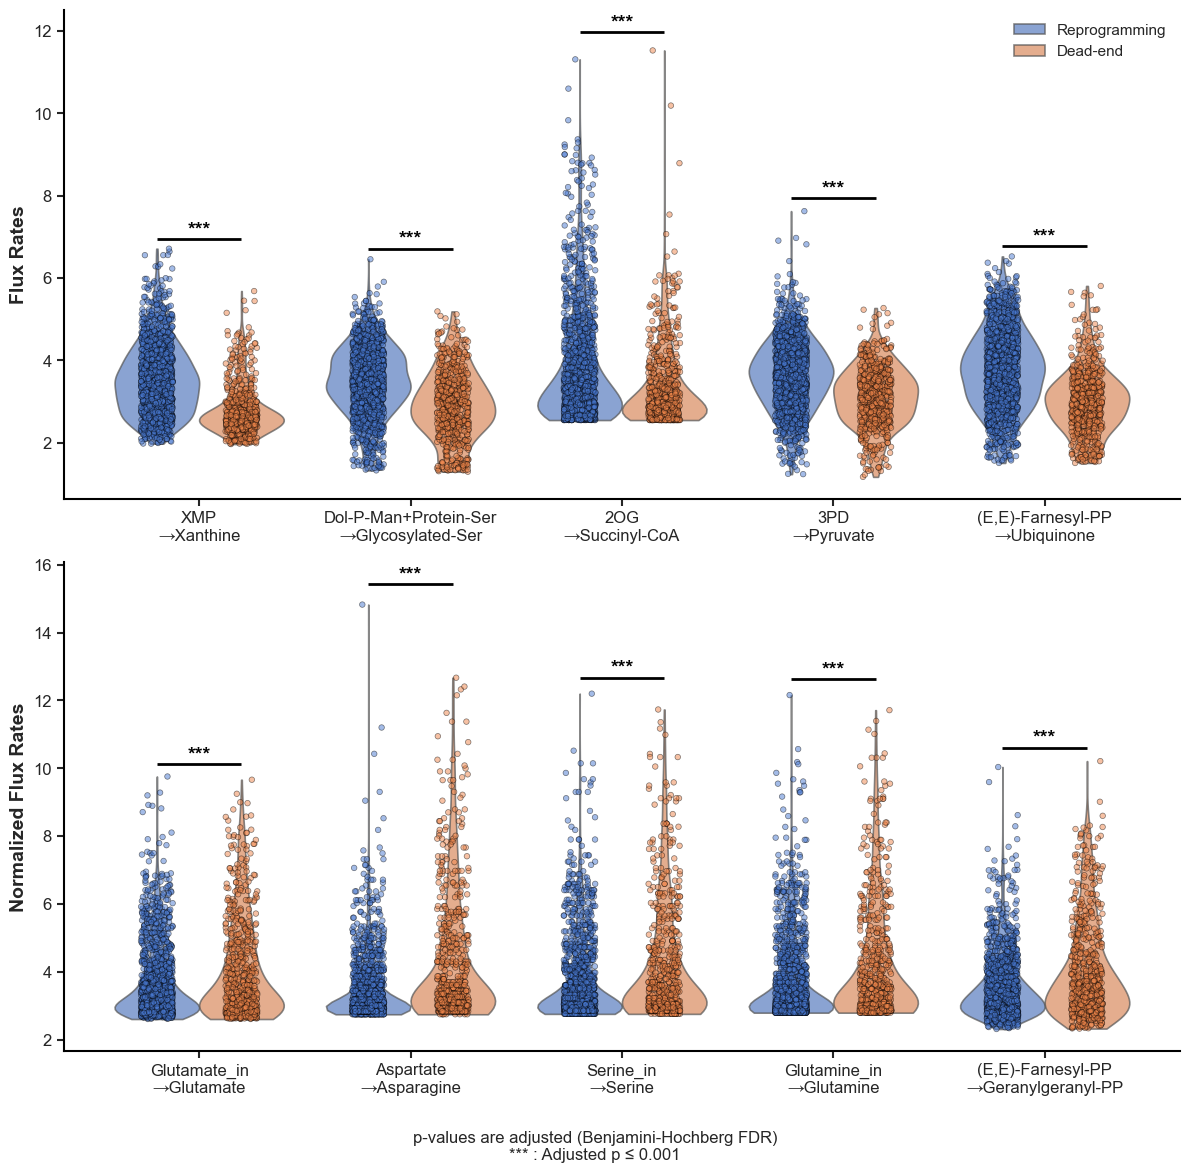

In [ ]:
def plot_top_fate_specific_reactions(df = df_features):
      
    flux_features = df[df.modality=='Flux']
    top_flux_markers_re = flux_features[flux_features.group=='reprogramming'].sort_values(by='mean_rank', ascending=True).head(5)
    top_flux_markers_de = flux_features[flux_features.group=='dead-end'].sort_values(by='mean_rank', ascending=True).head(5)

    def trim_feature(name):
        if name == "Dolichyl phosphate D-mannose+Protein serine→(Gal)1 (GlcNAc)1 (Man)1 (Ser/Thr)1":
            name = "Dol-P-Man+Protein-Ser→Glycosylated-Ser"
        if 'glutamate' in name:
            name = name.replace('glutamate', 'Glutamate')
        if 'serine' in name:
            name = name.replace('serine', 'Serine')

        return name if len(name) <= 50 else name[:47] + "..."

    def split_feature_label(name):
        return name.replace("→", "\n→")

    def significance_stars(p):
        """Converts p-values into significance stars."""
        if p <= 0.001:
            return '***'
        elif p <= 0.01:
            return '**'
        elif p <= 0.05:
            return '*'
        else:
            return ''

    top_features_re = top_flux_markers_re["feature"].tolist()
    top_features_de = top_flux_markers_de["feature"].tolist()

    # Order feature names for visualization
    order_re = [trim_feature(f) for f in top_features_re]
    order_de = [trim_feature(f) for f in top_features_de]

    # Compute significance markers
    signif_re = {trim_feature(row['feature']): significance_stars(row['pval_adj'])
                for _, row in top_flux_markers_re.sort_values(by="mean_rank").head(5).iterrows()}
    signif_de = {trim_feature(row['feature']): significance_stars(row['pval_adj'])
                for _, row in top_flux_markers_de.sort_values(by="mean_rank").head(5).iterrows()}

    # Prepare data in long format for seaborn plotting
    df_re = adata_Flux_labelled[top_features_re].copy()
    df_re["group"] = flux_labels.map(lambda x: x.capitalize())
    df_re_long = df_re.reset_index().melt(id_vars=["index", "group"], var_name="Feature", value_name="Value")
    df_re_long["Feature"] = df_re_long["Feature"].apply(trim_feature)

    df_de = adata_Flux_labelled[top_features_de].copy()
    df_de["group"] = flux_labels.map(lambda x: x.capitalize())
    df_de_long = df_de.reset_index().melt(id_vars=["index", "group"], var_name="Feature", value_name="Value")
    df_de_long["Feature"] = df_de_long["Feature"].apply(trim_feature)

    # Create figure with subplots
    fig, axes = plt.subplots(2, 1, sharey=False, figsize=(12, 12))

    # Define color palette for better contrast
    palette = "muted"

    # Plot for reprogramming features (Violin + Strip)
    sns.violinplot(x="Feature", y="Value", hue="group", data=df_re_long, palette=palette, ax=axes[0], order=order_re,
                cut=0, scale="width", inner=None, linewidth=1.2, alpha=0.7)

    sns.stripplot(x="Feature", y="Value", hue="group", data=df_re_long, palette=palette, ax=axes[0], order=order_re,
                dodge=True, jitter=0.15, alpha=0.5, edgecolor="black", linewidth=0.5, size=4, rasterized=True)

    axes[0].set_ylabel("Flux Rates")
    axes[0].set_xlabel("")
    # axes[0].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

    # Adjust x-axis labels for multi-line display
    axes[0].set_xticklabels([split_feature_label(label.get_text()) for label in axes[0].get_xticklabels()], fontsize=12)

    # Ensure dots are drawn on top of violin
    for strip in axes[0].collections:
        strip.set_zorder(3)

    # Plot for dead-end features (Violin + Strip)
    sns.violinplot(x="Feature", y="Value", hue="group", data=df_de_long, palette=palette, ax=axes[1], order=order_de,
                cut=0, scale="width", inner=None, linewidth=1.2, alpha=0.7)

    sns.stripplot(x="Feature", y="Value", hue="group", data=df_de_long, palette=palette, ax=axes[1], order=order_de,
                dodge=True, jitter=0.15, alpha=0.5, edgecolor="black", linewidth=0.5, size=4, rasterized=True)

    axes[1].set_ylabel("Normalized Flux Rates")
    axes[1].set_xlabel("")
    # axes[1].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

    # Adjust x-axis labels for multi-line display
    axes[1].set_xticklabels([split_feature_label(label.get_text()) for label in axes[1].get_xticklabels()], fontsize=12)

    # Ensure dots are drawn on top of violin
    for strip in axes[1].collections:
        strip.set_zorder(3)

    # Remove duplicate legends
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles[:2], labels[:2])
    axes[1].legend().set_visible(False)

    # Add significance markers
    for i, feat in enumerate(order_re):
        d = df_re_long[df_re_long["Feature"] == feat]["Value"]
        max_val = d.max()
        offset = (d.max() - d.min()) * 0.05 if (d.max() - d.min()) != 0 else 0.1
        star = signif_re.get(feat, '')

        if star:
            axes[0].hlines(y=max_val + offset, xmin=i - 0.2, xmax=i + 0.2, color="black", linewidth=2)
            axes[0].text(i, max_val + offset, star, ha="center", va="bottom", color="black", fontsize=14, fontweight="bold")

    for i, feat in enumerate(order_de):
        d = df_de_long[df_de_long["Feature"] == feat]["Value"]
        max_val = d.max()
        offset = (d.max() - d.min()) * 0.05 if (d.max() - d.min()) != 0 else 0.1
        star = signif_de.get(feat, '')

        if star:
            axes[1].hlines(y=max_val + offset, xmin=i - 0.2, xmax=i + 0.2, color="black", linewidth=2)
            axes[1].text(i, max_val + offset, star, ha="center", va="bottom", color="black", fontsize=14, fontweight="bold")

    # Add global significance legend
    fig.text(0.5, 0.02, "p-values are adjusted (Benjamini-Hochberg FDR)\n*** : Adjusted p ≤ 0.001", ha="center", va="center", fontsize=12)

    # Adjust layout and save figure with higher resolution for publication
    plt.tight_layout(rect=[0, 0.05, 1, 0.98])
    return fig


fig = plot_top_fate_specific_reactions()
plt.show()


In [27]:
df_features[(df_features.modality=='Flux')].sort_values(by='mean_rank', ascending=True).to_csv("metabolic_features.csv", index=False)

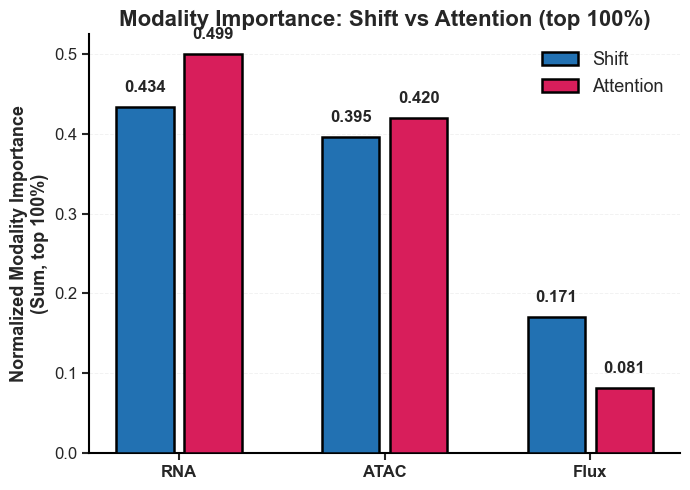

In [ ]:
def plot_modality_importance_combined(df_features, agg_method='sum', top_type='pct', top_value=100):

    modality_order = ['RNA', 'ATAC', 'Flux']
    modality_stats_list = []
    top_desc = ''
    
    for modality in modality_order:
        modality_df = df_features[df_features['modality'] == modality].copy()
        n_total = len(modality_df)
        if top_type == 'pct':
            n_features_shift = n_features_att = max(1, int(n_total * top_value / 100))
            top_desc = f"top {top_value}%"
        elif top_type == 'n':
            n_features_shift = n_features_att = min(top_value, n_total)
            top_desc = f"top {top_value}"
        else:
            raise ValueError("top_type must be 'pct' or 'n'")

        top_shift_df = modality_df.nlargest(n_features_shift, 'importance_shift')
        top_att_df = modality_df.nlargest(n_features_att, 'importance_att')

        if agg_method == 'sum':
            shift_value = top_shift_df['importance_shift'].sum()
            att_value = top_att_df['importance_att'].sum()
        elif agg_method == 'mean':
            shift_value = top_shift_df['importance_shift'].mean()
            att_value = top_att_df['importance_att'].mean()
        elif agg_method == 'median':
            shift_value = top_shift_df['importance_shift'].median()
            att_value = top_att_df['importance_att'].median()
        else:
            raise ValueError("agg_method must be 'sum', 'mean', or 'median'")

        modality_stats_list.append({
            'modality': modality,
            'importance_shift': shift_value,
            'importance_att': att_value
        })

    modality_stats = pd.DataFrame(modality_stats_list)
    shift_total = modality_stats['importance_shift'].sum()
    att_total = modality_stats['importance_att'].sum()
    if shift_total > 0:
        modality_stats['importance_shift'] /= shift_total
    if att_total > 0:
        modality_stats['importance_att'] /= att_total

    method_colors = {'Shift': '#2271B2', 'Attention': '#D81E5B'}
    methods = ['Shift', 'Attention']
    bar_colors = [method_colors['Shift'], method_colors['Attention']]

    x = np.arange(len(modality_stats))
    width = 0.28
    gap = 0.05

    fig, ax = plt.subplots(figsize=(7, 5))

    bars1 = ax.bar(x - width/2 - gap/2, modality_stats['importance_shift'], width=width, 
                   color=bar_colors[0], edgecolor='black', linewidth=1.8, label='Shift', zorder=3)
    bars2 = ax.bar(x + width/2 + gap/2, modality_stats['importance_att'], width=width, 
                   color=bar_colors[1], edgecolor='black', linewidth=1.8, label='Attention', zorder=3)

    ax.set_ylabel(f'Normalized Modality Importance\n({agg_method.capitalize()}, {top_desc})', fontsize=13, fontweight='bold')
    ax.set_title(f'Modality Importance: Shift vs Attention ({top_desc})', fontsize=16, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(modality_stats['modality'], fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.25, zorder=0)

    for bar, value in zip(bars1, modality_stats['importance_shift']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015, 
                f'{value:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    for bar, value in zip(bars2, modality_stats['importance_att']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015, 
                f'{value:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend(fontsize=13, frameon=False, loc='upper right')
    plt.tight_layout()
    return fig

fig = plot_modality_importance_combined(df_features, agg_method='sum', top_type='pct', top_value=100)

<Figure size 640x480 with 0 Axes>

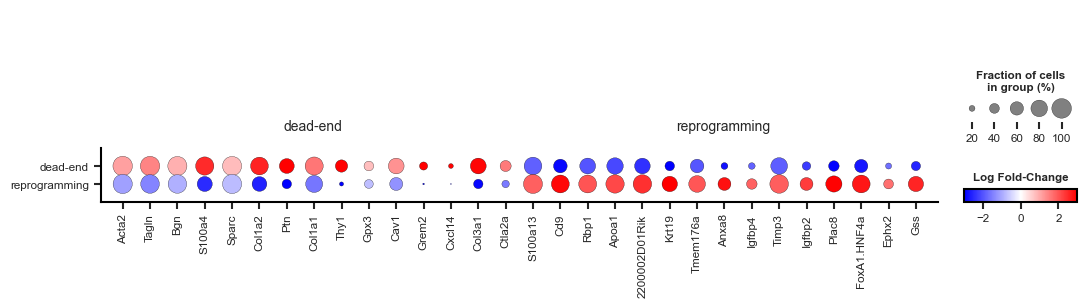

In [ ]:
top_rna_markers_de = df_features[df_features['modality'] == 'RNA'][df_features['group'] == 'dead-end']
top_rna_markers_re = df_features[df_features['modality'] == 'RNA'][df_features['group'] == 'reprogramming']

# Extract top marker genes
de_top = top_rna_markers_de.sort_values(by='mean_rank').head(15)['feature'].tolist()
re_top = top_rna_markers_re.sort_values(by='mean_rank').head(15)['feature'].tolist()
marker_genes_dict = {
    "dead-end": de_top,
    "reprogramming": re_top
}

# Normalize and log-transform RNA data
scaled_rna = adata_RNA_labelled.copy()
sc.pp.normalize_total(scaled_rna, target_sum=1e4)
sc.pp.log1p(scaled_rna)

# Perform differential gene expression analysis
sc.tl.rank_genes_groups(scaled_rna, groupby='label', method='wilcoxon', use_raw=False)

# Generate dot plot for log fold-change
plt.figure()  # Create a new figure
sc.pl.rank_genes_groups_dotplot(
    scaled_rna,
    groupby='label',  
    var_names=marker_genes_dict, 
    values_to_plot='logfoldchanges',  
    cmap='bwr',  
    vmin=-3, vmax=3,
    colorbar_title='Log Fold-Change', 
    show=False,
    use_raw=False,
    var_group_rotation=0,
    dendrogram=False
)
plt.show()
plt.close() 

In [32]:
# Export top 5% gene names in a text file
gene_count = df_features[df_features.modality == "RNA"].shape[0]
gene_count_5 = int(gene_count * 0.05)+1
top_5_genes_reprogramming = df_features[(df_features.modality == "RNA") & (df_features.group == "reprogramming")].sort_values(by='mean_rank', ascending=True).head(gene_count_5)["feature"].tolist()
with open("top_5_genes_reprogramming.txt", "w") as f:
    for gene in top_5_genes_reprogramming:
        f.write(gene.upper() + "\n")
top_5_genes_dead_end = df_features[(df_features.modality == "RNA") & (df_features.group == "dead-end")].sort_values(by='mean_rank', ascending=True).head(gene_count_5)["feature"].tolist()
with open("top_5_genes_deadend.txt", "w") as f:
    for gene in top_5_genes_dead_end:
        f.write(gene.upper() + "\n")
print(gene_count_5)

48


Reprogramming Reactome Pathways: {'Regulation of IGF transport and uptake by IGFBPs', 'Scavenging by Class A Receptors', 'Post-translational protein phosphorylation', 'Plasma lipoprotein assembly, remodeling, and clearance', 'Visual phototransduction', 'Chylomicron assembly', 'Plasma lipoprotein assembly', 'Plasma lipoprotein remodeling', 'Metabolism of fat-soluble vitamins', 'Chylomicron remodeling', 'Retinoid metabolism and transport'}
Dead-end Reactome Pathways: {'Degradation of the extracellular matrix', 'Collagen chain trimerization', 'Collagen formation', 'Signal Transduction', 'MET activates PTK2 signaling', 'Platelet activation, signaling and aggregation', 'Extracellular matrix organization', 'Assembly of collagen fibrils and other multimeric structures', 'NCAM1 interactions', 'ECM proteoglycans', 'Collagen biosynthesis and modifying enzymes', 'Non-integrin membrane-ECM interactions', 'Integrin cell surface interactions', 'Signaling by MET', 'Signaling by Receptor Tyrosine Kina

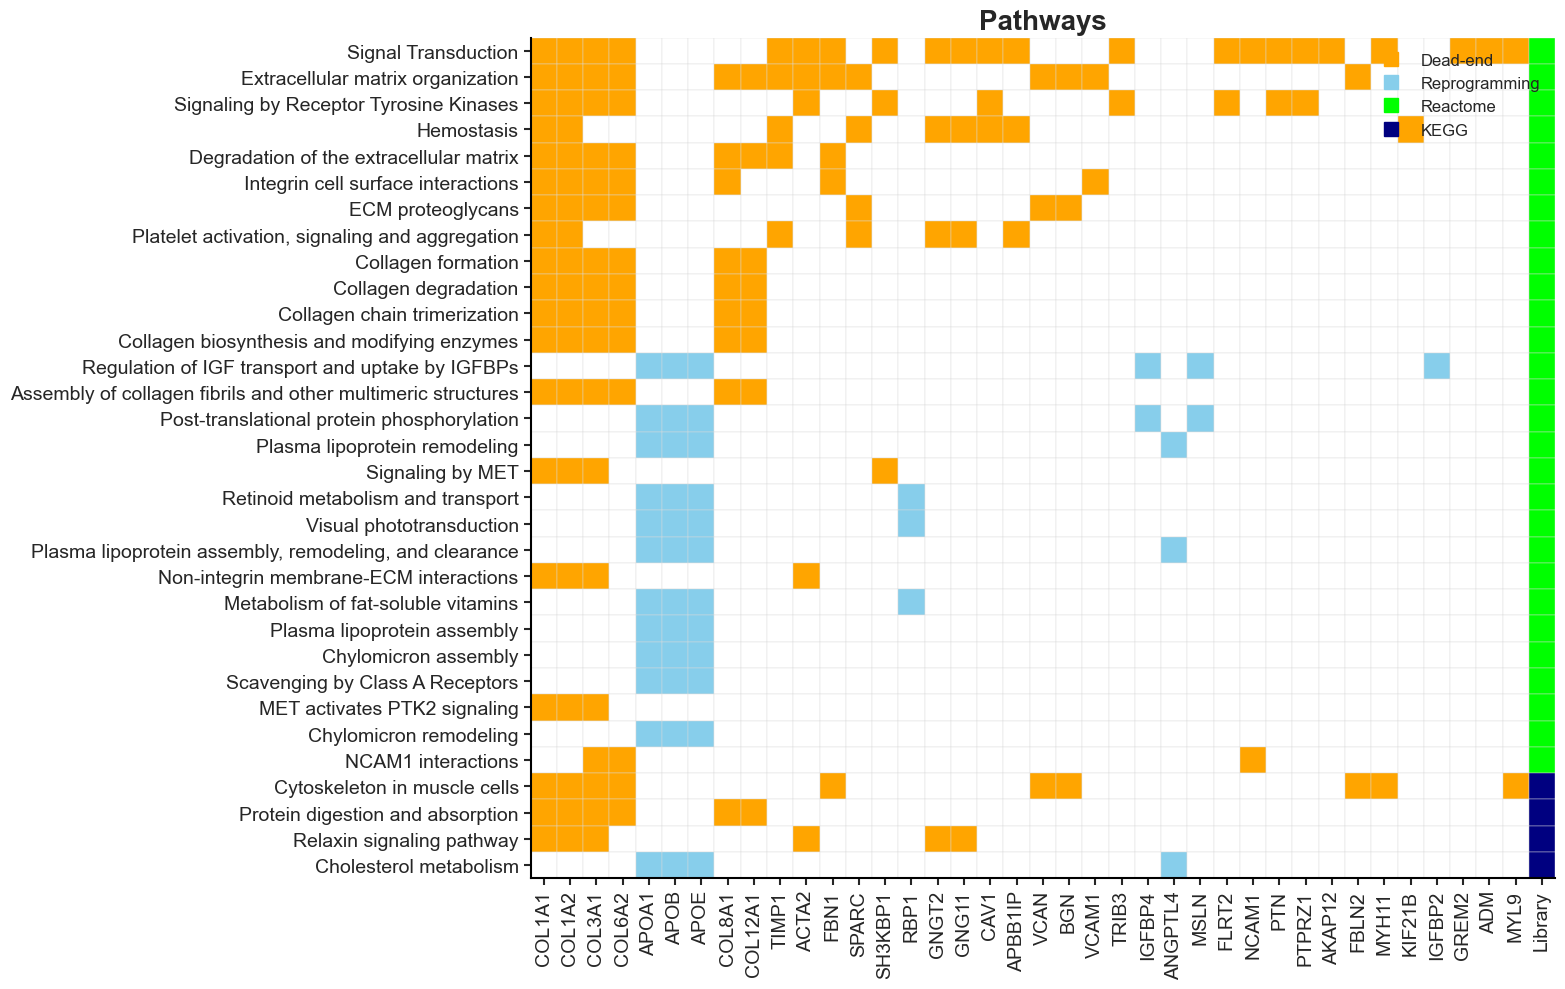

In [ ]:

mpl.rcParams["svg.image_inline"] = True
mpl.rcParams["svg.fonttype"] = "none"

de_all = pd.read_csv("analysis docs/DAVID_deadend", sep='\t')
re_all = pd.read_csv("analysis docs/DAVID_reprogramming", sep='\t')
reactome_dead_end = de_all[de_all["Category"] == "REACTOME_PATHWAY"]
reactome_reprogramming = re_all[re_all["Category"] == "REACTOME_PATHWAY"]
kegg_dead_end = de_all[de_all["Category"] == "KEGG_PATHWAY"]
kegg_reprogramming = re_all[re_all["Category"] == "KEGG_PATHWAY"]

def preprocess_data_with_label(df, label):
    df = df[['Term', 'Genes', 'Benjamini']].copy()
    df['Label'] = label
    exploded = df.set_index(['Term', 'Benjamini', 'Label'])['Genes'].str.split(', ').explode().reset_index()
    return exploded

def filter_and_preprocess(df, pval_threshold, splitter, label):
    df['Term'] = df['Term'].str.split(splitter).str[-1]
    if splitter == "-":
        df['Term'] = df['Term'].str.split("~").str[-1]
    # shorten length of term if it is too long; add ... if truncated
    def truncate_term(x):
        if len(x) > 60:
            return x[:60] + "..."
        return x
    df['Term'] = df['Term'].apply(truncate_term)
    filtered_df = df[df['Benjamini'] < pval_threshold]
    return preprocess_data_with_label(filtered_df, label), filtered_df

pval_threshold = 0.05

reactome_dead_end_data, _ = filter_and_preprocess(reactome_dead_end, pval_threshold, "~", "Dead-end")
reactome_reprogramming_data, _ = filter_and_preprocess(reactome_reprogramming, pval_threshold, "~", "Reprogramming")
reactome_combined_data = pd.concat([reactome_dead_end_data, reactome_reprogramming_data])

kegg_dead_end_data, _ = filter_and_preprocess(kegg_dead_end, pval_threshold, ":", "Dead-end")
kegg_reprogramming_data, _ = filter_and_preprocess(kegg_reprogramming, pval_threshold, ":", "Reprogramming")
kegg_combined_data = pd.concat([kegg_dead_end_data, kegg_reprogramming_data])

print("Reprogramming Reactome Pathways:" ,set(reactome_reprogramming_data.Term.tolist()))
print("Dead-end Reactome Pathways:" ,set(reactome_dead_end_data.Term.tolist()))
print("Reprogramming KEGG Pathways:" ,set(kegg_reprogramming_data.Term.tolist()))
print("Dead-end KEGG Pathways:" ,set(kegg_dead_end_data.Term.tolist()))

def create_binary_matrix(data):
    binary_matrix = pd.crosstab(data['Term'], data['Genes'])
    label_mapping = data.groupby('Term')['Label'].first()
    pvalues = data.groupby('Term')['Benjamini'].first()
    return binary_matrix, label_mapping, pvalues

reactome_matrix, reactome_labels, reactome_pvalues = create_binary_matrix(reactome_combined_data)
kegg_matrix, kegg_labels, kegg_pvalues = create_binary_matrix(kegg_combined_data)

def sort_matrix_by_gene_and_pathway_contribution(matrix):
    sorted_pathways = matrix.sum(axis=1).sort_values(ascending=False).index
    sorted_genes = matrix.sum(axis=0).sort_values(ascending=False).index
    sorted_matrix = matrix.loc[sorted_pathways, sorted_genes]
    return sorted_matrix

reactome_matrix = sort_matrix_by_gene_and_pathway_contribution(reactome_matrix)
kegg_matrix = sort_matrix_by_gene_and_pathway_contribution(kegg_matrix)

# %% Prepare the merged matrix with an extra "Library" column

# Create library mapping Series for each matrix.
reactome_library = pd.Series("Reactome", index=reactome_matrix.index)
kegg_library = pd.Series("KEGG", index=kegg_matrix.index)

# Merge the matrices vertically (using outer join to include all gene columns)
merged_matrix = pd.concat([reactome_matrix, kegg_matrix], axis=0, sort=False).fillna(0)
# Also merge the pathway label mappings (for enrichment: dead-end or reprogramming)
merged_labels = pd.concat([reactome_labels, kegg_labels])
# And merge the library mapping.
merged_library = pd.concat([reactome_library, kegg_library])

# to sort the merged matrix further (e.g. by the number of gene hits), you can do so:
# merged_matrix = merged_matrix.loc[merged_matrix.sum(axis=1).sort_values(ascending=False).index]
# merged_labels = merged_labels.loc[merged_matrix.index]
# merged_library = merged_library.loc[merged_matrix.index]

# Append an extra column to hold library info.
# The gene columns are the ones already in merged_matrix; we add one more column "Library"
merged_matrix["Library"] = 0  # will be overwritten with our library code

# %% Define color mappings.
# For pathway enrichment labels, we use the same as before.
GLOBAL_LABEL_COLORS = {"Dead-end": 1, "Reprogramming": 2}
# For the library annotation we assign:
GLOBAL_LIBRARY_COLORS = {"Reactome": 3, "KEGG": 4}

# Define a new color list that covers indices 0-4:
# 0: white (no gene), 1: dead-end (orange), 2: reprogramming (sky blue),
# 3: Reactome (lightgreen), 4: KEGG (lightblue)
new_color_list = ["white", "orange", "#87CEEB", "lime", "navy"]

# %% Create the merged matrix for plotting.
# We will produce an integer matrix where:
# - For gene columns, each cell is either 0 or (1 or 2) based on the pathway label.
# - For the extra "Library" column, we set 3 if Reactome, 4 if KEGG.

# Make a copy to hold color indices.
merged_matrix_colors = merged_matrix.copy()

# Identify gene columns (all columns except "Library")
gene_cols = merged_matrix_colors.columns.drop("Library")

# For each pathway (row), update gene cells and the library cell.
for term in merged_matrix_colors.index:
    # Get the enrichment label (dead-end or reprogramming) for this pathway.
    label = merged_labels.loc[term]
    label_index = GLOBAL_LABEL_COLORS[label]  # either 1 or 2
    # Multiply the binary (0/1) values for gene associations by the label index.
    merged_matrix_colors.loc[term, gene_cols] = merged_matrix_colors.loc[term, gene_cols] * label_index
    
    # Now, set the extra "Library" column based on which library this pathway comes from.
    lib = merged_library.loc[term]
    merged_matrix_colors.loc[term, "Library"] = GLOBAL_LIBRARY_COLORS[lib]

# %% Plot the merged matrix

def plot_merged_pathways(matrix, gene_columns, title="Pathways"):
    """
    Plot the merged pathways heatmap with an extra column showing library assignment,
    using one vector rectangle per cell for full Illustrator compatibility.
    """
    # map integer values to actual color codes
    value_to_color = {
        0: "white",           # no gene
        1: "orange",          # Dead end
        2: "#87CEEB",         # Reprogramming
        3: "lime",            # Reactome
        4: "navy",            # KEGG
    }

    n_rows, n_cols = matrix.shape

    fig, ax = plt.subplots(figsize=(15, 10), facecolor="white")
    ax.set_title(title, fontsize=20)

    # draw each cell as a rectangle
    for row in range(n_rows):
        for col in range(n_cols):
            val = int(matrix.iat[row, col])
            color = value_to_color.get(val, "white")
            rect = Rectangle(
                (col - 0.5, row - 0.5),   # lower left corner
                1.0,                      # width
                1.0,                      # height
                facecolor=color,
                edgecolor="gainsboro",
                linewidth=0.3
            )
            ax.add_patch(rect)

    # set limits so that cells line up
    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(n_rows - 0.5, -0.5)  # flip y axis so first row is at top
    ax.set_aspect("equal")

    # x labels
    x_labels = list(gene_columns) + ["Library"]
    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(x_labels, fontsize=14, rotation=90)

    # y labels
    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(matrix.index, fontsize=14)

    # turn off minor grid since we draw the borders ourselves
    ax.tick_params(which="both", bottom=True, left=True)

    # build legend
    legend_handles = []
    for label, idx in GLOBAL_LABEL_COLORS.items():
        if label in merged_labels.values:
            legend_handles.append(
                plt.Line2D([0], [0],
                           marker="s",
                           color=value_to_color[idx],
                           linestyle="None",
                           markersize=10,
                           label=label)
            )
    for lib, idx in GLOBAL_LIBRARY_COLORS.items():
        if lib in merged_library.values:
            legend_handles.append(
                plt.Line2D([0], [0],
                           marker="s",
                           color=value_to_color[idx],
                           linestyle="None",
                           markersize=10,
                           label=lib)
            )

    ax.legend(handles=legend_handles,
              fontsize=12,
              title_fontsize=14,
              loc="upper right")

    plt.tight_layout()
    plt.show()

plot_merged_pathways(merged_matrix_colors, gene_columns=gene_cols)


Found  9  significant  bp  GO terms
Found  26  significant  cc  GO terms
Found  9  significant  mf  GO terms
Reprogramming Biological Process GO Terms: ['cellular response to lipoprotein particle stimulus', 'triglyceride homeostasis', 'cholesterol homeostasis', 'lipid metabolic process', 'lipoprotein biosynthetic process']
Dead-end Biological Process GO Terms: ['cell adhesion', 'skeletal system development', 'extracellular matrix organization', 'cellular response to transforming growth factor beta stimulus']
Reprogramming Cellular Component GO Terms: ['1_extracellular space', '0_intermediate-density lipoprotein particle', '0_apical plasma membrane', '0_chylomicron', '0_low-density lipoprotein particle', '0_microvillus', '0_very-low-density lipoprotein particle', '0_cell periphery', '0_high-density lipoprotein particle', '0_sarcolemma', '1_cytoskeleton', '0_cytosol', '0_discoidal high-density lipoprotein particle']
Dead-end Cellular Component GO Terms: ['0_extracellular space', '0_extra

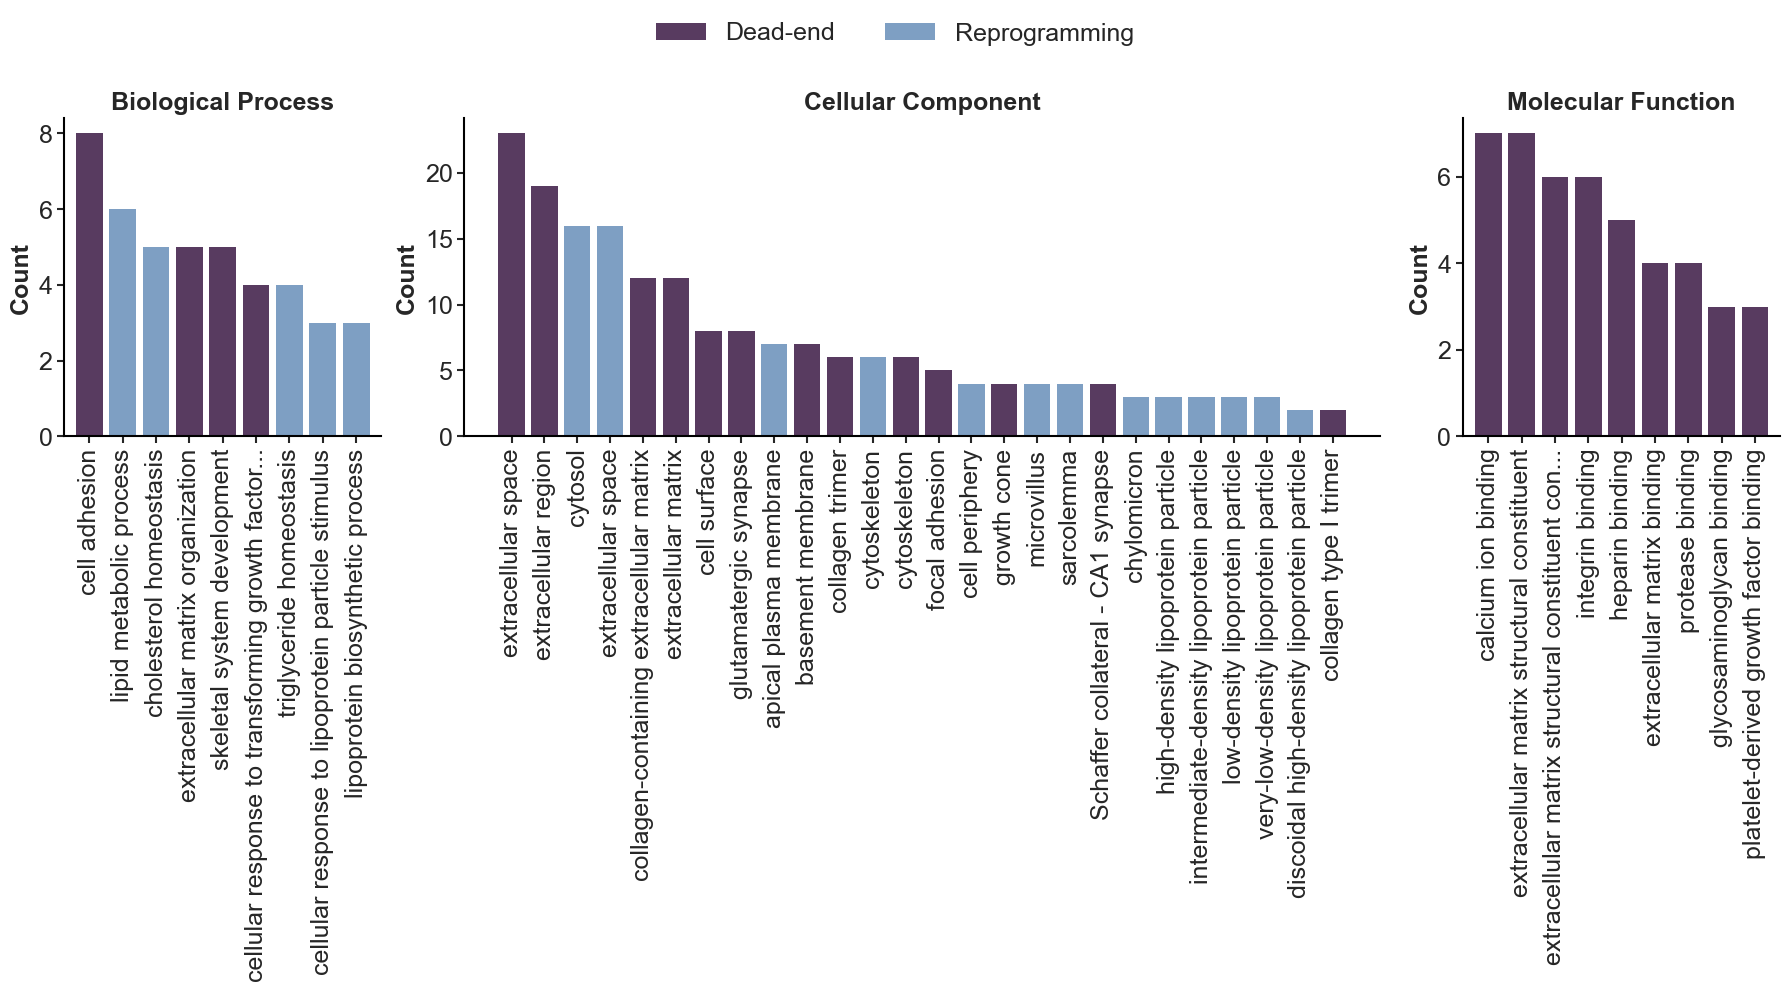

In [ ]:
mpl.rcParams['pdf.fonttype'] = 42  # Use TrueType fonts for PDF
# -----------------------------
# Helper function to trim labels
# -----------------------------
def trim_label(label, max_length=50):
    """Trim label to max_length. If trimmed, append '...'."""
    return label if len(label) <= max_length else label[:max_length-3] + "..."

# -----------------------------
# Define a function to load and label a GO file
# -----------------------------
def load_go_category(category):
    """
    Loads the dead-end and reprogramming GO files for a given category.
    category: one of 'bp', 'cc', or 'mf'
    Returns a combined DataFrame with an added column 'Group'.
    """
    pval_threshold = 0.05
    key = "GOTERM_" + category.upper() + "_DIRECT"
    df_de = de_all[de_all["Category"] == key]
    df_de = df_de[df_de["Benjamini"] < pval_threshold]
    df_de["Term"] = df_de["Term"].apply(lambda x: x.split('~')[-1])
    df_de["Group"] = "Dead-end"
    df_re = re_all[re_all["Category"] == key]
    df_re = df_re[df_re["Benjamini"] < pval_threshold]
    df_re["Term"] = df_re["Term"].apply(lambda x: x.split('~')[-1])
    df_re["Group"] = "Reprogramming"
    df = pd.concat([df_de, df_re], ignore_index=True)
    if category == "cc":
        # This ensures the terms are unique by prefixing them with a counter.
        df['Term'] = df.groupby('Term').cumcount().astype(str) + '_' + df['Term']
    print("Found ", len(df), " significant ", category, " GO terms")
    return df

# Load data for each category
df_bp = load_go_category("bp")
df_cc = load_go_category("cc")
df_mf = load_go_category("mf")

# -----------------------------
# Define a fixed color mapping for the groups.
# -----------------------------
group_colors = {"Dead-end": "#5c3566ff", "Reprogramming": "#729fcfff"}

# -----------------------------
# Determine the order for the GO terms in each category.
# We order by the total count across both groups (in descending order).
# -----------------------------
order_bp = df_bp.groupby("Term")["Count"].sum().sort_values(ascending=False).index.tolist()
order_cc = df_cc.groupby("Term")["Count"].sum().sort_values(ascending=False).index.tolist()
order_mf = df_mf.groupby("Term")["Count"].sum().sort_values(ascending=False).index.tolist()


print("Reprogramming Biological Process GO Terms:", df_bp[df_bp.Group=='Reprogramming']['Term'].tolist())
print("Dead-end Biological Process GO Terms:", df_bp[df_bp.Group=='Dead-end']['Term'].tolist())
print("Reprogramming Cellular Component GO Terms:", df_cc[df_cc.Group=='Reprogramming']['Term'].tolist())
print("Dead-end Cellular Component GO Terms:", df_cc[df_cc.Group=='Dead-end']['Term'].tolist())
print("Reprogramming Molecular Function GO Terms:", df_mf[df_mf.Group=='Reprogramming']['Term'].tolist())
print("Dead-end Molecular Function GO Terms:", df_mf[df_mf.Group=='Dead-end']['Term'].tolist())
# -----------------------------
# Calculate subplot widths so that each bar has the same physical width.
# -----------------------------
# Count how many bars will be in each subplot:
n_bp = len(order_bp)
n_cc = len(order_cc)
n_mf = len(order_mf)

# When using seaborn.barplot, the default bar width is 0.8 (in data coordinates)
# In a given axis, the conversion from data units to inches is (axis_width_in_inches / n_bars).
# Thus, the physical bar width is:
#   physical_bar_width = (axis_width_in_inches / n_bars) * 0.8
# To get a desired physical bar width (say, 0.5 inches), set:
#   axis_width_in_inches = (desired_bar_width / 0.8) * n_bars
desired_bar_width = 0.5  # inches
default_bar_width = 0.8  # (data units used by seaborn.barplot)

# Compute required width for each subplot:
ax_width_bp = (desired_bar_width / default_bar_width) * n_bp
ax_width_cc = (desired_bar_width / default_bar_width) * n_cc
ax_width_mf = (desired_bar_width / default_bar_width) * n_mf

# Set margins between subplots (in inches). With 3 subplots there are 2 gaps.
wspace_inches = 1  # for example, 1 inch gap between subplots

# Total width for all subplots:
total_axes_width = ax_width_bp + ax_width_cc + ax_width_mf

# Total figure width = axes widths + gaps
fig_width = total_axes_width + 2 * wspace_inches

# -----------------------------
# Create the figure with 3 subplots using gridspec with calculated width ratios.
# -----------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 10),
    gridspec_kw={'width_ratios': [ax_width_bp, ax_width_cc, ax_width_mf]}
)

# -----------------------------
# Plot for Biological Process (BP)
# -----------------------------
sns.barplot(
    data=df_bp, x="Term", y="Count", hue="Group", 
    palette=group_colors, order=order_bp, ax=axes[0],
    edgecolor='none'
)
axes[0].set_title("Biological Process", fontsize=18)
axes[0].set_xlabel("", fontsize=18)
axes[0].set_ylabel("Count", fontsize=18)
axes[0].tick_params(axis='x', rotation=90)
# Update tick labels with trimmed names
axes[0].set_xticklabels([trim_label(label) for label in order_bp], fontsize=18)
axes[0].yaxis.set_tick_params(labelsize=18)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].margins(x=0.04)

# -----------------------------
# Plot for Cellular Component (CC)
# -----------------------------
sns.barplot(
    data=df_cc, x="Term", y="Count", hue="Group", 
    palette=group_colors, order=order_cc, ax=axes[1],
    edgecolor='none'
)
# For CC, remove the added counter prefix and then trim the label.
axes[1].set_xticklabels([trim_label(label.split('_')[1]) for label in order_cc], fontsize=18)
axes[1].set_title("Cellular Component", fontsize=18)
axes[1].set_xlabel("", fontsize=18)
axes[1].set_ylabel("Count", fontsize=18)
axes[1].tick_params(axis='x', rotation=90)
axes[1].yaxis.set_tick_params(labelsize=18)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].margins(x=0.04)

# -----------------------------
# Plot for Molecular Function (MF)
# -----------------------------
sns.barplot(
    data=df_mf, x="Term", y="Count", hue="Group", 
    palette=group_colors, order=order_mf, ax=axes[2],
    edgecolor='none'
)
axes[2].set_title("Molecular Function", fontsize=18)
axes[2].set_xlabel("", fontsize=18)
axes[2].set_ylabel("Count", fontsize=18)
axes[2].tick_params(axis='x', rotation=90)
# Update tick labels with trimmed names
axes[2].set_xticklabels([trim_label(label) for label in order_mf], fontsize=18)
axes[2].yaxis.set_tick_params(labelsize=18)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].margins(x=0.04)

# -----------------------------
# Remove individual legends and create one common legend at the top center.
# -----------------------------
handles, labels = axes[0].get_legend_handles_labels()
# Remove legends from individual plots
axes[0].legend_.remove()
axes[1].legend_.remove()
axes[2].legend_.remove()
# Create one legend for the entire figure
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=18, title_fontsize=12)

plt.tight_layout(rect=[0.0, 0, 1, 0.92])
plt.show()


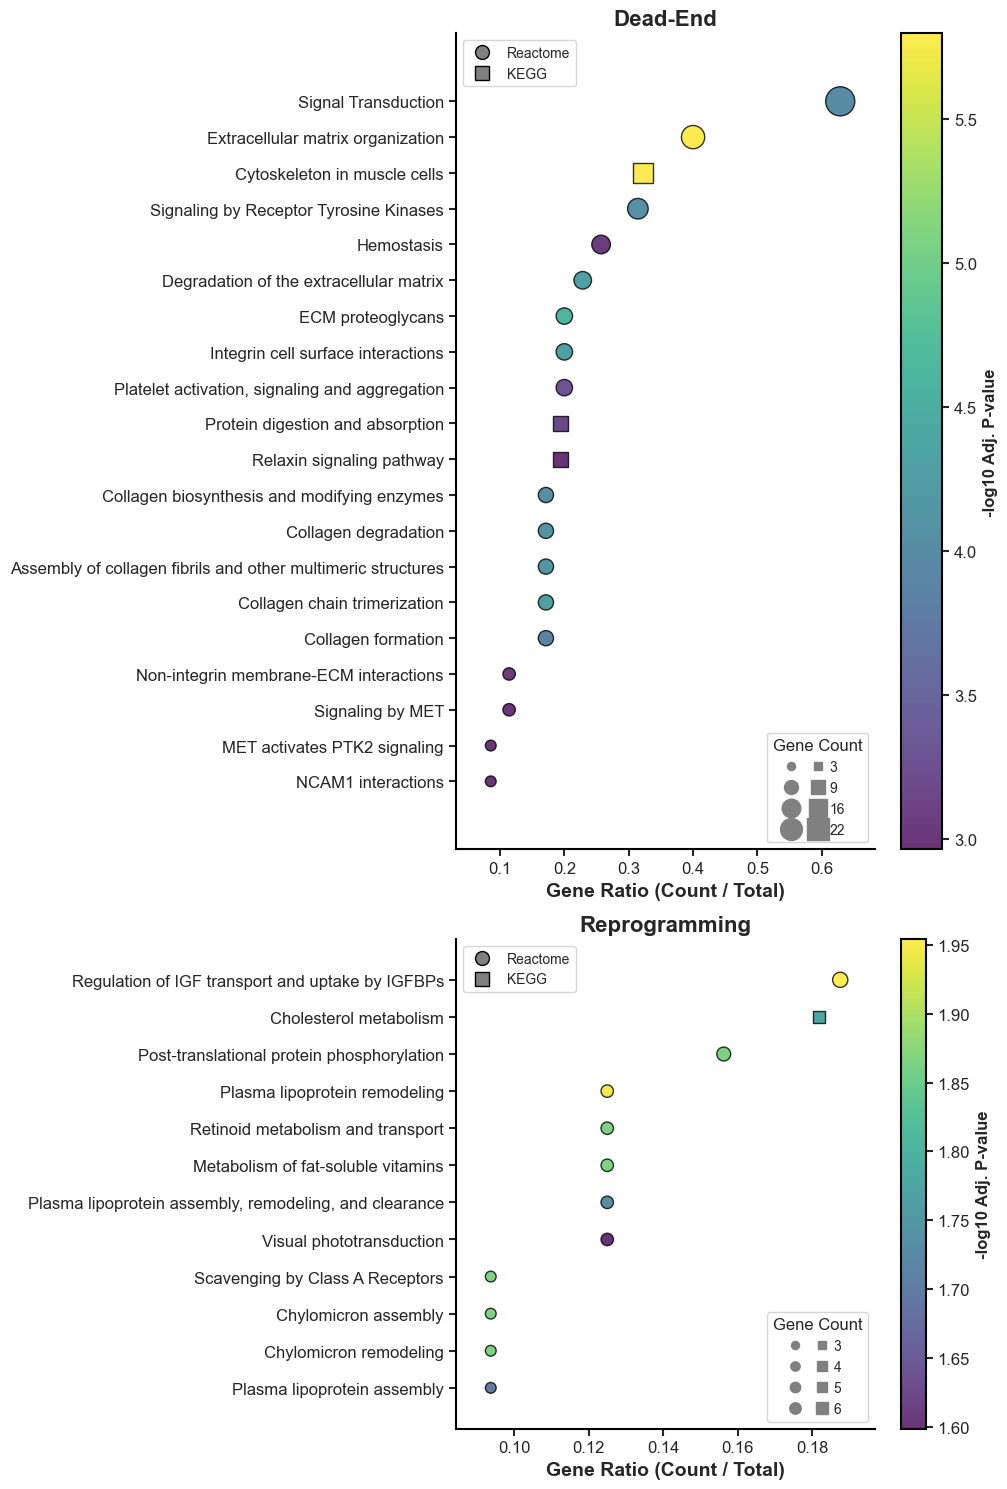

In [ ]:
def preprocess_file(df, splitter):

    
    df['Term'] = df['Term'].str.split(splitter).str[-1]
    if splitter == "-":
        df['Term'] = df['Term'].str.split("~").str[-1]
    
    # Filter for significant pathways
    df = df[df['Benjamini'] < 0.05].copy()
    
    # Compute Gene Ratio (Count / List Total)
    df['Gene Ratio'] = df['Count'] / df['List Total']
    return df

def plot_gene_ratio_bubble_merged(dead_end_df, reprogramming_df, title, save_path):

    from matplotlib.legend_handler import HandlerBase
    marker_shapes = {"Reactome": "o", "KEGG": "s"}
    n_dead_end = len(dead_end_df) if not dead_end_df.empty else 1
    n_reprogramming = len(reprogramming_df) if not reprogramming_df.empty else 1
    fig, axes = plt.subplots(2, 1, figsize=(10, 15), gridspec_kw={'height_ratios': [n_dead_end, n_reprogramming]})
    for ax, (df, condition) in zip(axes, [(dead_end_df, "Dead-End"), (reprogramming_df, "Reprogramming")]):
        if df.empty:
            ax.text(0.5, 0.5, "No Significant Pathways", fontsize=14, ha='center')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        df = df.copy()
        df['Display_Term'] = df['Term']
        df = df.sort_values(by='Gene Ratio', ascending=False).reset_index(drop=True)
        df['y_pos'] = df.index
        scatter_obj = None
        for lib, marker in marker_shapes.items():
            subset = df[df['Library'] == lib]
            if not subset.empty:
                scatter_obj = ax.scatter(subset['Gene Ratio'], subset['y_pos'], s=subset['Count'] * 20, c=-np.log10(subset['Benjamini']), cmap='viridis', alpha=0.8, edgecolors='black', marker=marker, label=lib)
        ax.set_xlabel('Gene Ratio (Count / Total)', fontsize=14)
        ax.set_title(f"{condition}", fontsize=16)
        ax.set_yticks(df['y_pos'])
        ax.set_yticklabels(df['Display_Term'], fontsize=12)
        ax.invert_yaxis()
        if not df['Gene Ratio'].empty:
            min_x, max_x = df['Gene Ratio'].min(), df['Gene Ratio'].max()
            padding = (max_x - min_x) * 0.1 if (max_x - min_x) > 0 else 0.1
            ax.set_xlim(min_x - padding, max_x + padding)
        ax.margins(y=0.1, x=0.15)
        if scatter_obj is not None:
            cbar = fig.colorbar(scatter_obj, ax=ax)
            cbar.set_label('-log10 Adj. P-value', fontsize=12)
        min_count = df['Count'].min()
        max_count = df['Count'].max()
        if min_count == max_count:
            legend_counts = [min_count]
        else:
            legend_counts = np.linspace(min_count, max_count, 4)
            legend_counts = [int(round(x)) for x in legend_counts]
        class HandlerDualMarker(HandlerBase):
            def create_artists(self, legend, orig_handle, x0, y0, width, height, fontsize, trans):
                cx = x0 + width/2 
                cy = y0 + height/2
                offset = width/2
                offset_y = height/5
                size = np.sqrt(orig_handle['size']) * 0.75
                a1 = plt.Line2D([cx - offset], [cy], marker=orig_handle['marker1'], color='gray', markerfacecolor='gray', markersize=size, linestyle='')
                a2 = plt.Line2D([cx + offset], [cy], marker=orig_handle['marker2'], color='gray', markerfacecolor='gray', markersize=size, linestyle='')
                return [a1, a2]
        dummy_handles = []
        for count in legend_counts:
            dummy_handles.append({'marker1': 'o', 'marker2': 's', 'size': count * 20})
        size_legend = ax.legend(dummy_handles, [str(x) for x in legend_counts], title='Gene Count', loc='lower right', frameon=True, fontsize=10, title_fontsize=12, handler_map={dict: HandlerDualMarker()})
        ax.add_artist(size_legend)
        lib_handles = []
        for lib, marker in marker_shapes.items():
            lib_handles.append(plt.Line2D([], [], marker=marker, color='w', markerfacecolor='gray', markeredgecolor='black', markersize=10, label=lib))
        ax.legend(handles=lib_handles, loc='upper left', frameon=True, fontsize=10, title_fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    plt.show()


reactome_dead_end = de_all[de_all["Category"] == "REACTOME_PATHWAY"]
reactome_reprogramming = re_all[re_all["Category"] == "REACTOME_PATHWAY"]
kegg_dead_end = de_all[de_all["Category"] == "KEGG_PATHWAY"]
kegg_reprogramming = re_all[re_all["Category"] == "KEGG_PATHWAY"]

reactome_dead_end_data = preprocess_file(reactome_dead_end, "~")
reactome_dead_end_data["Library"] = "Reactome"
reactome_reprogramming_data = preprocess_file(reactome_reprogramming, "~")
reactome_reprogramming_data["Library"] = "Reactome"

kegg_dead_end_data = preprocess_file(kegg_dead_end, ":")
kegg_dead_end_data["Library"] = "KEGG"
kegg_reprogramming_data = preprocess_file(kegg_reprogramming, ":")
kegg_reprogramming_data["Library"] = "KEGG"

merged_dead_end = pd.concat([reactome_dead_end_data, kegg_dead_end_data], ignore_index=True)
merged_reprogramming = pd.concat([reactome_reprogramming_data, kegg_reprogramming_data], ignore_index=True)

dataset_name = "Merged Reactome & KEGG Pathway Enrichment"

plot_gene_ratio_bubble_merged(
    merged_dead_end,
    merged_reprogramming,
    dataset_name,
    "gene_ratio_bubble_plot_merged.pdf"
)

<Figure size 640x480 with 0 Axes>

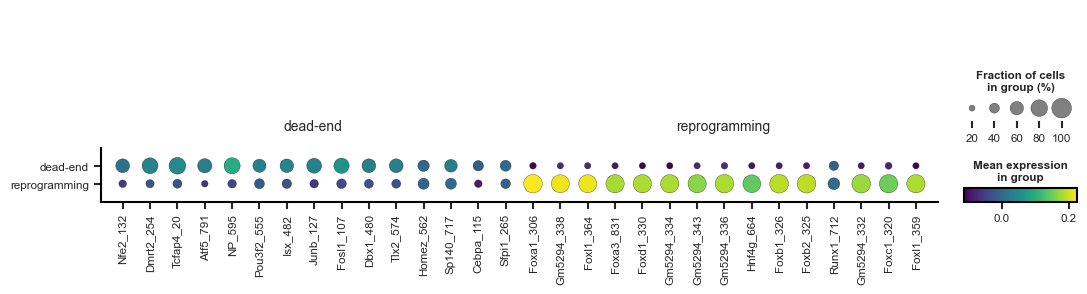

In [ ]:

top_atac_markers = df_features[df_features['modality'] == 'ATAC']
de_top = top_atac_markers[top_atac_markers['group'] == 'dead-end'].sort_values(by='mean_rank').head(15)['feature'].tolist()
de_vals = top_atac_markers[top_atac_markers['group'] == 'dead-end'].sort_values(by='mean_rank').head(15)['mean_rank'].tolist()
re_top = top_atac_markers[top_atac_markers['group'] == 'reprogramming'].sort_values(by='mean_rank').head(15)['feature'].tolist()
re_vals = top_atac_markers[top_atac_markers['group'] == 'reprogramming'].sort_values(by='mean_rank').head(15)['mean_rank'].tolist()
marker_tf_dict = {
    "dead-end": de_top,
    "reprogramming": re_top
}

rank_genes_groups = {'names': {}, 'logfoldchanges': {}, 'pvals': {}, 'pvals_adj': {}, 'scores': {}}
rank_genes_groups['names'] = top_atac_markers['feature'].values
rank_genes_groups['logfoldchanges'] = top_atac_markers['log_fc'].values

scaled_atac = adata_ATAC_labelled.copy()
plt.figure()
dotplot = sc.pl.dotplot(scaled_atac, marker_tf_dict, groupby='label', cmap='viridis', show=False, use_raw=False, var_group_rotation=0)
plt.show()
plt.close() 

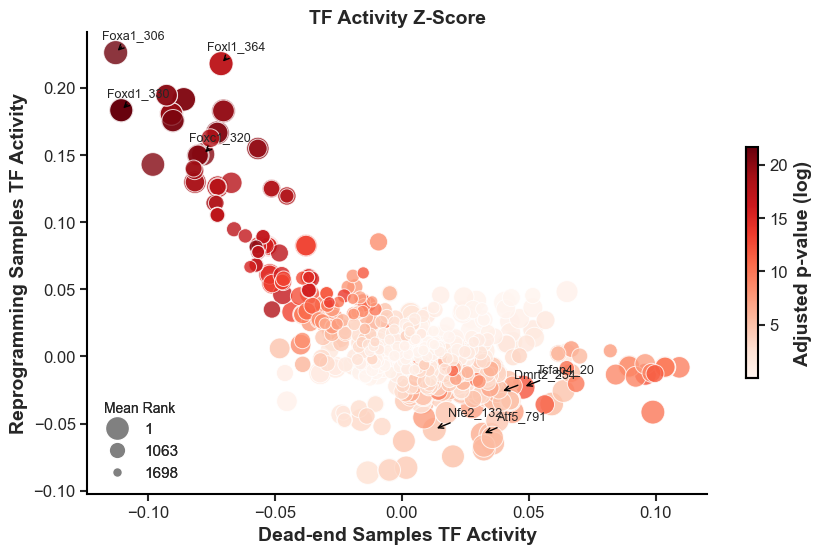

In [ ]:
max_rank = atac_combined_df['mean_rank'].max()
atac_combined_df['inverse_rank'] = max_rank - atac_combined_df['mean_rank']
p = "Reds"

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=atac_combined_df, x='mean_de', y='mean_re',
    size='inverse_rank', hue='pval_adj_log',
    sizes=(50, 300), palette=p,
    alpha=0.8, edgecolor='w', rasterized=True,
    legend=False
)

norm = plt.Normalize(
    atac_combined_df['pval_adj_log'].min(),
    atac_combined_df['pval_adj_log'].max()
)
sm = plt.cm.ScalarMappable(cmap=p, norm=norm)
sm.set_array([])

# Add the 'shrink' parameter to reduce the colorbar's size.
cbar = plt.colorbar(sm, ax=ax, shrink=0.5)
cbar.set_label('Adjusted p-value (log)')

inv_min = atac_combined_df['inverse_rank'].min()
inv_max = atac_combined_df['inverse_rank'].max()
size_min, size_max = 50, 300

def map_size(inv):
    return ((inv - inv_min) / (inv_max - inv_min)) * (size_max - size_min) + size_min

actual_min = atac_combined_df['mean_rank'].min()
actual_med = np.median(atac_combined_df['mean_rank'])
actual_max = atac_combined_df['mean_rank'].max()

inv_for_min = max_rank - actual_min
inv_for_med = max_rank - actual_med
inv_for_max = max_rank - actual_max

size_val_min = map_size(inv_for_min)
size_val_med = map_size(inv_for_med)
size_val_max = map_size(inv_for_max)

legend_handles = [
    Line2D([], [], marker='o', color='w', markerfacecolor='gray',
           markersize=np.sqrt(size_val_min), label=f"{int(actual_min)}"),
    Line2D([], [], marker='o', color='w', markerfacecolor='gray',
           markersize=np.sqrt(size_val_med), label=f"{int(actual_med)}"),
    Line2D([], [], marker='o', color='w', markerfacecolor='gray',
           markersize=np.sqrt(size_val_max), label=f"{int(actual_max)}")
]

size_legend = ax.legend(handles=legend_handles, title="Mean Rank", loc="lower left")
ax.add_artist(size_legend)

dead_end_top = atac_combined_df[atac_combined_df['group'] == 'dead-end'].nsmallest(4, 'mean_rank')
dead_end_top = ['Nfe2_132', 'Dmrt2_254', 'Tcfap4_20', 'Atf5_791']
reprogramming_top = atac_combined_df[atac_combined_df['group'] == 'reprogramming'].nsmallest(4, 'mean_rank')
reprogramming_top = ['Foxa1_306', 'Foxc1_320', 'Foxd1_330', 'Foxl1_364']
for f in dead_end_top:
    row = atac_combined_df[atac_combined_df['feature'] == f]
    ax.annotate(
        row['feature'].tolist()[0],
        xy=(row['mean_de'], row['mean_re']),
        xytext=(10, 10), textcoords='offset points',
        arrowprops=dict(arrowstyle="->", color='black'),
        fontsize=9
    )

for f in reprogramming_top:
    row = atac_combined_df[atac_combined_df['feature'] == f]
    ax.annotate(
        row['feature'].tolist()[0],
        xy=(row['mean_de'], row['mean_re']),
        xytext=(-10, 10), textcoords='offset points',
        arrowprops=dict(arrowstyle="->", color='black'),
        fontsize=9
    )

plt.xlabel("Dead-end Samples TF Activity")
plt.ylabel("Reprogramming Samples TF Activity")
plt.title("TF Activity Z-Score")
sns.despine()
plt.show()


TF Heatmaps (9, 2)            Dead-end  Reprogramming
feature                           
Foxa1_306 -0.112726       0.226130
Foxc1_320 -0.078247       0.150447
Foxd1_330 -0.110524       0.183258
Foxl1_364 -0.071203       0.217929
NP_595     0.098921      -0.041456
Tcfap4_20  0.047740      -0.022908
Atf5_791   0.031711      -0.057887
Dmrt2_254  0.038894      -0.026386
Fosl1_107  0.059068      -0.035410
Gene Expression Heatmap (9, 2) group  dead-end  reprogramming
Foxa1  0.018206       0.030524
Foxc1  0.049399       0.070757
Foxd1  0.027121       0.031040
Foxl1  0.001848       0.002757
Pnp    0.322281       0.371609
Tfap4  0.026138       0.025543
Atf5   0.477394       0.213573
Dmrt2  0.002629       0.003614
Fosl1  0.077360       0.066654


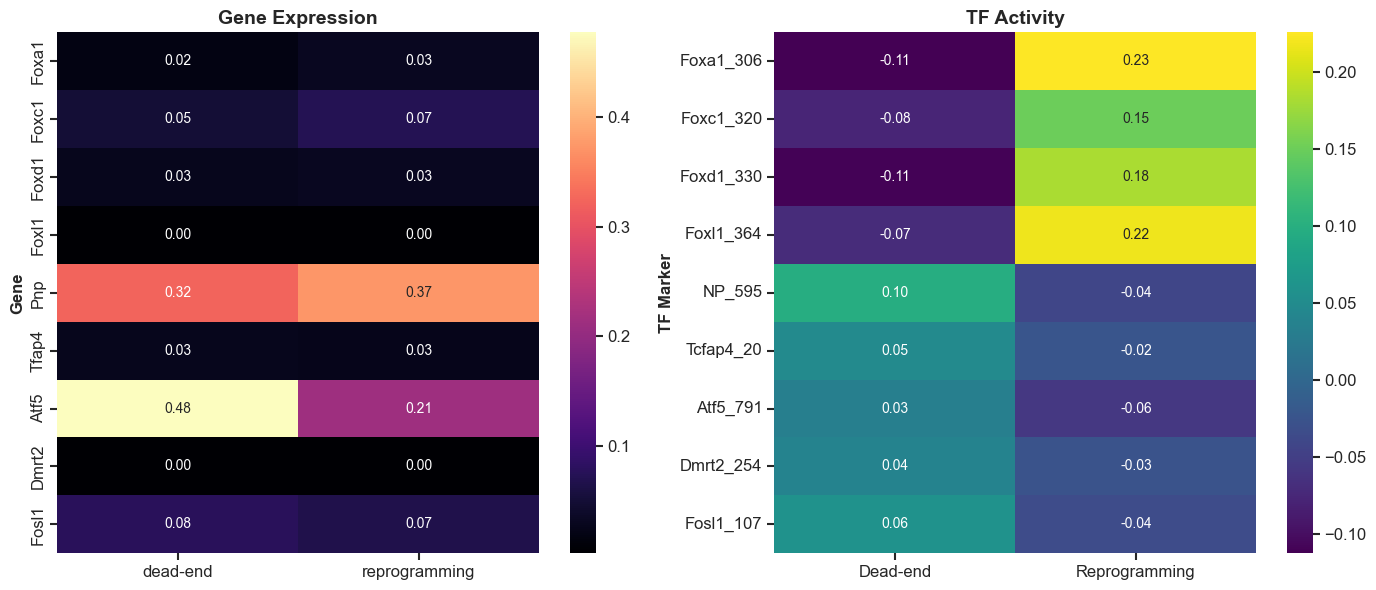

In [ ]:
atac_df = atac_combined_df.copy()
top_tfs = ['Foxa1_306', 'Foxc1_320', 'Foxd1_330', 'Foxl1_364', 'NP_595', 'Tcfap4_20', 'Atf5_791', 'Dmrt2_254', 'Fosl1_107']
top_tf_genes = ['Foxa1', 'Foxc1', 'Foxd1', 'Foxl1', 'Pnp', 'Tfap4', 'Atf5', 'Dmrt2', 'Fosl1']

top_atac = atac_df[atac_df['feature'].isin(top_tfs)].set_index('feature')
atac_heatmap = top_atac[['mean_de', 'mean_re']].rename(columns={'mean_de':'Dead-end', 'mean_re':'Reprogramming'})
atac_heatmap = atac_heatmap.loc[top_tfs]

rna_data = adata_RNA_labelled_all
adata_subset = rna_data[:, top_tf_genes]
if hasattr(adata_subset.X, "toarray"):
    expr_data = adata_subset.X.toarray()
else:
    expr_data = adata_subset.X
expr_df = pd.DataFrame(expr_data, columns=adata_subset.var_names, index=adata_subset.obs_names)
expr_df['group'] = adata_subset.obs['label'].values
expr_group_mean = expr_df.groupby('group').mean().T
expr_group_mean = expr_group_mean.loc[top_tf_genes]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax0, ax1 = axes

sns.heatmap(expr_group_mean, annot=True, cmap='magma', fmt=".2f", ax=ax0)
ax0.set_title("Gene Expression", fontsize=14)
ax0.set_ylabel("Gene", fontsize=12)
ax0.set_xlabel("")

sns.heatmap(atac_heatmap, annot=True, cmap='viridis', fmt=".2f", ax=ax1)
ax1.set_title("TF Activity", fontsize=14)
ax1.set_ylabel("TF Marker", fontsize=12)
ax1.set_xlabel("")

print("TF Heatmaps", atac_heatmap.shape, atac_heatmap)
print("Gene Expression Heatmap", expr_group_mean.shape, expr_group_mean)
plt.tight_layout()
plt.show()
